In [1]:
# Multimodal Fake News Detection with Vision-Language Models
### Complete single-notebook implementation


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
# 2. Environment Setup

Installs only what Colab does not already ship. `torch` / `torchvision` are left at Colab's preinstalled versions deliberately - reinstalling them is the single most common cause of a broken CUDA build.

In [3]:
import socket
try:
    print("DNS:", socket.gethostbyname("pypi.org"))
    print("network OK")
except Exception as e:
    print("network FAILED ->", e)

DNS: 151.101.64.223
network OK


In [4]:
!cat /etc/resolv.conf
!curl -s -m 10 -o /dev/null -w "%{http_code}\n" https://pypi.org || echo "curl failed"

# Generated by Docker Engine.
# This file can be edited; Docker Engine will not make further changes once it
# has been modified.

nameserver 127.0.0.11
search asia-southeast1-c.c.codatalab-user-runtimes.internal c.codatalab-user-runtimes.internal google.internal
options ndots:0

# Based on host file: '/etc/resolv.conf' (internal resolver)
# ExtServers: [169.254.169.254]
# Overrides: [search]
# Option ndots from: internal
200


In [5]:
# ============================================================================
# DEPENDENCIES - Kaggle
# Kaggle already ships numpy, pandas, scipy, scikit-learn, torch, torchvision,
# matplotlib, tqdm, pillow, requests, psutil. Only the missing pieces are
# installed here, in ONE resolver pass.
# jupyterlab / ipykernel / notebook / ipywidgets are deliberately NOT touched -
# upgrading them breaks huggingface_hub, which in turn breaks peft.
# ============================================================================

!pip install -q \
    "transformers>=4.45,<5.0" \
    "peft>=0.11,<1.0" \
    "accelerate>=0.30" \
    "huggingface-hub>=0.24" \
    "safetensors>=0.4" \
    "sentencepiece>=0.2" \
    "xgboost>=2.0,<4.0" \
    "gdown>=5.1" 2>&1 | tail -5

# ---- hard gate: if peft cannot import, Section 17 will fail later ----------
import importlib
_ok = True
for _m in ["transformers", "peft", "accelerate", "huggingface_hub",
           "safetensors", "xgboost"]:
    try:
        _mod = importlib.import_module(_m)
        print(f"  {_m:<18} {getattr(_mod, '__version__', 'ok')}")
    except Exception as _e:
        print(f"  {_m:<18} FAILED -> {_e}")
        _ok = False

if not _ok:
    raise RuntimeError(
        "A dependency failed to import. Do NOT continue - Section 17 (LoRA) "
        "will break. Fix the versions above first."
    )

print("\nAll dependencies installed and importable.")

  transformers       4.57.6
  peft               0.20.0
  accelerate         1.14.0
  huggingface_hub    0.36.2
  safetensors        0.8.0
  xgboost            3.4.1

All dependencies installed and importable.


In [6]:
# Verify all imports work
import numpy as np
import pandas as pd
import torch
import transformers
import sklearn
import scipy
from PIL import Image
import matplotlib.pyplot as plt

print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("PyTorch version:", torch.__version__)
print("Transformers version:", transformers.__version__)
print("Scikit-learn version:", sklearn.__version__)

if torch.cuda.is_available():
    print(f"\n GPU: {torch.cuda.get_device_name(0)}")
    print(f" GPU Memory: {round(torch.cuda.get_device_properties(0).total_memory/2**30, 1)} GB")
else:
    print("\n WARNING: GPU not detected!")
    print("   PyTorch was installed as CPU-only.")
    print("   Make sure you installed from: https://download.pytorch.org/whl/cu126")

print("\n Setup complete! Ready to run Section 1 onwards.")

NumPy version: 2.1.3
Pandas version: 2.2.3
PyTorch version: 2.11.0+cu128
Transformers version: 4.57.6
Scikit-learn version: 1.6.1

 GPU: NVIDIA A100-SXM4-40GB
 GPU Memory: 39.5 GB

 Setup complete! Ready to run Section 1 onwards.


In [7]:
import os, sys, re, json, time, gc, io, math, random, hashlib, warnings, shutil, unicodedata, html
from pathlib import Path
from collections import defaultdict, Counter
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torchvision
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = False   # we WANT truncated files to raise, so we can log them

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, confusion_matrix,
                             classification_report, roc_curve, precision_recall_curve)

warnings.filterwarnings("ignore")
%matplotlib inline

IN_COLAB = "google.colab" in sys.modules

VERSIONS = {
    "python": sys.version.split()[0],
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "torch": torch.__version__,
    "torchvision": torchvision.__version__,
}
try:
    import transformers; VERSIONS["transformers"] = transformers.__version__
except Exception as e: VERSIONS["transformers"] = f"MISSING ({e})"
try:
    import peft; VERSIONS["peft"] = peft.__version__
except Exception as e: VERSIONS["peft"] = f"MISSING ({e})"
try:
    import xgboost; VERSIONS["xgboost"] = xgboost.__version__
except Exception as e: VERSIONS["xgboost"] = f"MISSING ({e})"
try:
    import sklearn; VERSIONS["scikit-learn"] = sklearn.__version__
except Exception as e: VERSIONS["scikit-learn"] = f"MISSING ({e})"

print(f"Running in Colab: {IN_COLAB}")
for k, v in VERSIONS.items():
    print(f"  {k:<15} {v}")

Running in Colab: True
  python          3.13.15
  numpy           2.1.3
  pandas          2.2.3
  torch           2.11.0+cu128
  torchvision     0.26.0+cu128
  transformers    4.57.6
  peft            0.20.0
  xgboost         3.4.1
  scikit-learn    1.6.1


---
# 3. File Menu Setup

Everything expensive is written to Drive so a disconnected session costs nothing but the current cell.

In [8]:
from pathlib import Path
import os, shutil

from google.colab import drive
drive.mount("/content/drive")

PROJECT_ROOT = Path("/content/drive/MyDrive/fake_news_multimodal")

DIRS = {
    "raw":         PROJECT_ROOT / "data" / "raw",
    "processed":   PROJECT_ROOT / "data" / "processed",
    "images":      PROJECT_ROOT / "data" / "images",
    "splits":      PROJECT_ROOT / "data" / "splits",
    "checkpoints": PROJECT_ROOT / "models" / "checkpoints",
    "cached":      PROJECT_ROOT / "models" / "cached_models",
    "embeddings":  PROJECT_ROOT / "embeddings",
    "metrics":     PROJECT_ROOT / "results" / "metrics",
    "figures":     PROJECT_ROOT / "results" / "figures",
    "predictions": PROJECT_ROOT / "results" / "predictions",
    "logs":        PROJECT_ROOT / "logs",
}
for p in DIRS.values():
    p.mkdir(parents=True, exist_ok=True)

os.environ["HF_HOME"] = str(DIRS["cached"])
os.environ["TRANSFORMERS_CACHE"] = str(DIRS["cached"] / "transformers")
os.environ["TORCH_HOME"] = str(DIRS["cached"] / "torch")

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
for k, v in DIRS.items():
    print(f"  {k:<12} {v}")

total, used, free = shutil.disk_usage("/content")
print(f"\nFree disk: {free/2**30:.1f} GB")
print("\nDrive storage setup complete.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_ROOT = /content/drive/MyDrive/fake_news_multimodal
  raw          /content/drive/MyDrive/fake_news_multimodal/data/raw
  processed    /content/drive/MyDrive/fake_news_multimodal/data/processed
  images       /content/drive/MyDrive/fake_news_multimodal/data/images
  splits       /content/drive/MyDrive/fake_news_multimodal/data/splits
  checkpoints  /content/drive/MyDrive/fake_news_multimodal/models/checkpoints
  cached       /content/drive/MyDrive/fake_news_multimodal/models/cached_models
  embeddings   /content/drive/MyDrive/fake_news_multimodal/embeddings
  metrics      /content/drive/MyDrive/fake_news_multimodal/results/metrics
  figures      /content/drive/MyDrive/fake_news_multimodal/results/figures
  predictions  /content/drive/MyDrive/fake_news_multimodal/results/predictions
  logs         /content/drive/MyDrive/fake_news_multimodal/logs

Free d

---
# 4. GPU and Hardware Check

Batch sizes are chosen from measured VRAM rather than hard-coded, so the notebook runs unchanged on a T4 (15 GB), an L4 (22 GB) or CPU-only.

In [9]:
HW = {}
HW["cuda_available"] = torch.cuda.is_available()

if HW["cuda_available"]:
    HW["gpu_name"] = torch.cuda.get_device_name(0)
    props = torch.cuda.get_device_properties(0)
    HW["vram_gb"] = round(props.total_memory / 2**30, 2)
    HW["cuda_version"] = torch.version.cuda
    HW["capability"] = f"{props.major}.{props.minor}"
    DEVICE = torch.device("cuda")
else:
    HW["gpu_name"] = "none"; HW["vram_gb"] = 0.0
    HW["cuda_version"] = "n/a"; HW["capability"] = "n/a"
    DEVICE = torch.device("cpu")

try:
    import psutil
    HW["ram_gb"] = round(psutil.virtual_memory().total / 2**30, 2)
    HW["cpu_count"] = psutil.cpu_count()
except Exception:
    HW["ram_gb"] = -1.0
    HW["cpu_count"] = os.cpu_count()

# bf16 needs Ampere (SM 8.0+); T4 is SM 7.5 so it gets fp16.
HW["amp_dtype"] = "none"
if HW["cuda_available"]:
    HW["amp_dtype"] = "bfloat16" if torch.cuda.is_bf16_supported() else "float16"
AMP_DTYPE = {"bfloat16": torch.bfloat16, "float16": torch.float16, "none": torch.float32}[HW["amp_dtype"]]
USE_AMP = HW["cuda_available"]

v = HW["vram_gb"]
if   v >= 22: BATCH = {"resnet": 128, "clip": 256, "blip2": 32, "head": 1024, "lora": 64}
elif v >= 14: BATCH = {"resnet":  64, "clip": 128, "blip2": 16, "head": 1024, "lora": 32}
elif v >=  9: BATCH = {"resnet":  32, "clip":  64, "blip2":  8, "head":  512, "lora": 16}
elif v >   0: BATCH = {"resnet":  16, "clip":  32, "blip2":  4, "head":  512, "lora":  8}
else:         BATCH = {"resnet":  16, "clip":  16, "blip2":  2, "head":  256, "lora":  4}

print("HARDWARE")
for k, val in HW.items(): print(f"  {k:<16} {val}")
print("\nSELECTED BATCH SIZES")
for k, val in BATCH.items(): print(f"  {k:<16} {val}")
print(f"\nDevice: {DEVICE} | mixed precision: {HW['amp_dtype']}")

if not HW["cuda_available"]:
    print("\n*** WARNING: no GPU. Runtime -> Change runtime type -> T4 GPU. ***")
    print("    BLIP-2 extraction on CPU is not practical.")

HARDWARE
  cuda_available   True
  gpu_name         NVIDIA A100-SXM4-40GB
  vram_gb          39.49
  cuda_version     12.8
  capability       8.0
  ram_gb           83.47
  cpu_count        12
  amp_dtype        bfloat16

SELECTED BATCH SIZES
  resnet           128
  clip             256
  blip2            32
  head             1024
  lora             64

Device: cuda | mixed precision: bfloat16


---
# 5. Configuration

One config object. Every downstream cell reads from it, and it is written to Drive so any run can be reconstructed exactly.

**`TARGET_N` is the single knob that controls project scale.** It is set to 20,000 for the pilot. Raising it towards the proposal's 100,000-200,000 changes nothing else in the notebook - only how long Section 9 spends downloading images.

In [10]:
CFG = {
    "seed": 42,

    # ---- scale -------------------------------------------------------
    "target_n": 20000,          # final class-balanced working set
    "pilot_url_probe": 500,     # URLs sampled to measure the live-image rate
    "image_size": 224,          # all three backbones use 224x224
    "jpeg_quality": 92,

    # ---- split -------------------------------------------------------
    "split_train": 0.70, "split_val": 0.15, "split_test": 0.15,

    # ---- duplicate detection ----------------------------------------
    "minhash_perms": 128, "minhash_bands": 16,
    "shingle_k": 5, "jaccard_threshold": 0.80,
    "phash_hamming_threshold": 6,

    # ---- models ------------------------------------------------------
    "clip_model":  "openai/clip-vit-base-patch32",
    "blip2_model": "Salesforce/blip2-itm-vit-g",
    "resnet_weights": "IMAGENET1K_V2",

    # ---- head training ----------------------------------------------
    "head_hidden": 512, "head_dropout": 0.3,
    "head_lr": 1e-3, "head_weight_decay": 1e-4,
    "head_max_epochs": 15, "head_patience": 3,
    "head_seeds": [42, 43, 44],

    # ---- LoRA (Section 17) ------------------------------------------
    "run_lora": True,
    "lora_r": 8, "lora_alpha": 16, "lora_dropout": 0.05,
    "lora_lr": 1e-4, "lora_epochs": 3, "lora_patience": 1,

    # ---- misc --------------------------------------------------------
    "download_workers": 16,
    "download_timeout": 12,
    "download_retries": 2,
    "cv_folds": 5,
}
CFG["batch"] = BATCH
CFG["hardware"] = HW
CFG["versions"] = VERSIONS

SEED = CFG["seed"]

def seed_everything(seed=SEED, deterministic=True):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    return seed

seed_everything()

with open(DIRS["logs"] / "config.json", "w") as f:
    json.dump(CFG, f, indent=2, default=str)

print(json.dumps({k: v for k, v in CFG.items() if k not in ("hardware", "versions")},
                 indent=2, default=str))
print(f"\nSeeds fixed at {SEED}. Config saved to {DIRS['logs'] / 'config.json'}")

{
  "seed": 42,
  "target_n": 20000,
  "pilot_url_probe": 500,
  "image_size": 224,
  "jpeg_quality": 92,
  "split_train": 0.7,
  "split_val": 0.15,
  "split_test": 0.15,
  "minhash_perms": 128,
  "minhash_bands": 16,
  "shingle_k": 5,
  "jaccard_threshold": 0.8,
  "phash_hamming_threshold": 6,
  "clip_model": "openai/clip-vit-base-patch32",
  "blip2_model": "Salesforce/blip2-itm-vit-g",
  "resnet_weights": "IMAGENET1K_V2",
  "head_hidden": 512,
  "head_dropout": 0.3,
  "head_lr": 0.001,
  "head_weight_decay": 0.0001,
  "head_max_epochs": 15,
  "head_patience": 3,
  "head_seeds": [
    42,
    43,
    44
  ],
  "run_lora": true,
  "lora_r": 8,
  "lora_alpha": 16,
  "lora_dropout": 0.05,
  "lora_lr": 0.0001,
  "lora_epochs": 3,
  "lora_patience": 1,
  "download_workers": 16,
  "download_timeout": 12,
  "download_retries": 2,
  "cv_folds": 5,
  "batch": {
    "resnet": 128,
    "clip": 256,
    "blip2": 32,
    "head": 1024,
    "lora": 64
  }
}

Seeds fixed at 42. Config saved to /conte

In [11]:
# ---- small utilities used throughout ---------------------------------

def cache_npz(path, build_fn, force=False):
    path = Path(path)
    if path.exists() and not force:
        print(f"[cache HIT ] {path.name}")
        with np.load(path, allow_pickle=True) as z:
            return {k: z[k] for k in z.files}
    print(f"[cache MISS] {path.name} - computing...")
    out = build_fn()
    np.savez_compressed(path, **out)
    print(f"[cache SAVE] {path.name}  ({path.stat().st_size/2**20:.1f} MB)")
    return out

def cache_df(path, build_fn, force=False):
    path = Path(path)
    if path.exists() and not force:
        print(f"[cache HIT ] {path.name}")
        return pd.read_parquet(path)
    print(f"[cache MISS] {path.name} - computing...")
    df = build_fn()
    df.to_parquet(path, index=False)
    print(f"[cache SAVE] {path.name}  ({path.stat().st_size/2**20:.1f} MB)")
    return df

def free_gpu():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache(); torch.cuda.synchronize()

def show(df, n=10, title=None):
    if title: print(f"\n=== {title} ===")
    with pd.option_context("display.max_columns", 60, "display.width", 220):
        print(df.head(n).to_string())

def savefig(name):
    p = DIRS["figures"] / name
    plt.tight_layout(); plt.savefig(p, dpi=130, bbox_inches="tight"); plt.show(); plt.close()
    print(f"[figure] {p}")

RESULTS = {}   # populated only by executed code; printed in Section 21
def record(model, split, metrics):
    RESULTS.setdefault(model, {})[split] = metrics
    with open(DIRS["metrics"] / "results.json", "w") as f:
        json.dump(RESULTS, f, indent=2, default=float)

print("Utilities ready.")

Utilities ready.


---
# 6. Dataset load

**Source:** Fakeddit (Nakamura, Levy and Wang, 2020), official release at `github.com/entitize/Fakeddit`.

The official metadata is distributed through Google Drive links published in that repository's README. Rather than hard-coding a file ID that may have been rotated, the notebook **reads the README and extracts the current links**, then downloads with `gdown`. That way the provenance record below reports the link that was actually used on the day you ran it.

Order of attempts:

1. Files already in `data/raw/` -> **skip download entirely**
2. Official GitHub README -> Google Drive links -> `gdown`
3. Kaggle API (only if `kaggle.json` is present and step 2 failed)
4. Stop with instructions for a manual drop into `data/raw/`

Only the three `multimodal_*` TSVs are fetched. The comment corpus and the pre-packaged image archive are not required by the proposal and are not downloaded.

In [12]:
# ============================================================
# FAKEDDIT DATASET — MANUAL LOCAL DATASET
# ============================================================

REQUIRED_TSVS = [
    "multimodal_train.tsv",
    "multimodal_validate.tsv",
    "multimodal_test_public.tsv"
]

# Manual dataset location
FAKEDDIT_RAW_DIR = Path(
    "/content/drive/MyDrive/New Project/data/raw"
)

PROVENANCE_PATH = DIRS["logs"] / "dataset_provenance.json"


def _present(d):
    """
    Check whether all required Fakeddit TSV files exist
    in the manually provided dataset directory.
    """
    d = Path(d)
    found = {}

    for name in REQUIRED_TSVS:
        path = d / name

        if path.is_file():
            size_mb = path.stat().st_size / 2**20

            if path.stat().st_size > 1_000_000:
                found[name] = path
                print(f"  Found: {name} ({size_mb:.1f} MB)")
            else:
                print(f"  WARNING: {name} exists but is too small "
                      f"({size_mb:.2f} MB)")

    return found


def acquire_fakeddit():
    """
    Use the manually downloaded Fakeddit TSV files.
    No automatic downloading is performed.
    """

    print("Checking manually downloaded Fakeddit dataset...")
    print(f"Dataset directory:\n{FAKEDDIT_RAW_DIR}\n")

    # Check directory
    if not FAKEDDIT_RAW_DIR.exists():
        raise FileNotFoundError(
            f"Fakeddit dataset directory does not exist:\n"
            f"{FAKEDDIT_RAW_DIR}\n\n"
            "Please create the folder and place these files inside:\n"
            + "\n".join(f"  - {x}" for x in REQUIRED_TSVS)
        )

    # Check required files
    have = _present(FAKEDDIT_RAW_DIR)

    missing = [name for name in REQUIRED_TSVS if name not in have]

    if missing:
        raise FileNotFoundError(
            "\nMissing required Fakeddit file(s):\n"
            + "\n".join(f"  - {x}" for x in missing)
            + "\n\nExpected location:\n"
            + str(FAKEDDIT_RAW_DIR)
        )

    print("\nAll required Fakeddit TSV files are present.")
    print("Using manually downloaded dataset.")
    print("Automatic download is disabled.\n")

    return have, {
        "method": "manual_download",
        "source": "Fakeddit official dataset",
        "directory": str(FAKEDDIT_RAW_DIR)
    }


# ============================================================
# LOAD DATASET
# ============================================================

tsv_paths, PROVENANCE = acquire_fakeddit()


# ============================================================
# DATASET PROVENANCE / FILE HASHES
# ============================================================

PROVENANCE["files"] = {}

for name, path in tsv_paths.items():

    h = hashlib.md5()

    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(2**20), b""):
            h.update(chunk)

    PROVENANCE["files"][name] = {
        "path": str(path),
        "size_bytes": path.stat().st_size,
        "size_mb": round(path.stat().st_size / 2**20, 2),
        "md5": h.hexdigest()
    }


PROVENANCE["retrieved_utc"] = time.strftime(
    "%Y-%m-%dT%H:%M:%SZ",
    time.gmtime()
)

PROVENANCE["citation"] = (
    "Nakamura, K., Levy, S. and Wang, W.Y. (2020) "
    "'r/Fakeddit: a new multimodal benchmark dataset for "
    "fine-grained fake news detection', LREC 2020, pp. 6149-6157."
)


# ============================================================
# SAVE PROVENANCE
# ============================================================

with open(PROVENANCE_PATH, "w") as f:
    json.dump(PROVENANCE, f, indent=2)


# ============================================================
# FINAL STATUS
# ============================================================

print("\n" + "=" * 60)
print("DATASET PROVENANCE")
print("=" * 60)

print(json.dumps(PROVENANCE, indent=2))

print("\nFakeddit dataset is ready.")

Checking manually downloaded Fakeddit dataset...
Dataset directory:
/content/drive/MyDrive/New Project/data/raw

  Found: multimodal_train.tsv (148.4 MB)
  Found: multimodal_validate.tsv (15.6 MB)
  Found: multimodal_test_public.tsv (15.6 MB)

All required Fakeddit TSV files are present.
Using manually downloaded dataset.
Automatic download is disabled.


DATASET PROVENANCE
{
  "method": "manual_download",
  "source": "Fakeddit official dataset",
  "directory": "/content/drive/MyDrive/New Project/data/raw",
  "files": {
    "multimodal_train.tsv": {
      "path": "/content/drive/MyDrive/New Project/data/raw/multimodal_train.tsv",
      "size_bytes": 155656851,
      "size_mb": 148.45,
      "md5": "b0c5068fa516d1f3103032524df82693"
    },
    "multimodal_validate.tsv": {
      "path": "/content/drive/MyDrive/New Project/data/raw/multimodal_validate.tsv",
      "size_bytes": 16343460,
      "size_mb": 15.59,
      "md5": "abf58021972218fd88c4c6b80741fb56"
    },
    "multimodal_test_pub

---
# 7. Dataset Inspection

Nothing is modified here. The three official files are loaded and pooled into a single corpus, because Section 12 re-splits at group level (deviation 4).

Every figure below is computed from the loaded data.

In [13]:
def load_pool():
    frames = []
    for name, path in tsv_paths.items():
        df = pd.read_csv(path, sep="\t", low_memory=False)
        df["orig_split"] = name.replace("multimodal_", "").replace(".tsv", "")
        frames.append(df)
        print(f"  {name:<32} {df.shape[0]:>8,} rows x {df.shape[1]:>2} cols")
    pool = pd.concat(frames, ignore_index=True)
    return pool

pool = load_pool()
print(f"\nPooled corpus: {pool.shape[0]:,} rows x {pool.shape[1]} columns")
print(f"\nColumns: {list(pool.columns)}")

  multimodal_train.tsv              564,000 rows x 17 cols
  multimodal_validate.tsv            59,342 rows x 17 cols
  multimodal_test_public.tsv         59,319 rows x 17 cols

Pooled corpus: 682,661 rows x 17 columns

Columns: ['author', 'clean_title', 'created_utc', 'domain', 'hasImage', 'id', 'image_url', 'linked_submission_id', 'num_comments', 'score', 'subreddit', 'title', 'upvote_ratio', '2_way_label', '3_way_label', '6_way_label', 'orig_split']


In [14]:
print("=== DTYPES AND MISSINGNESS ===")
info = pd.DataFrame({
    "dtype":     pool.dtypes.astype(str),
    "n_missing": pool.isna().sum(),
    "pct_missing": (pool.isna().sum() / len(pool) * 100).round(2),
    "n_unique":  pool.nunique(dropna=True),
})
print(info.to_string())

# --- identify the id / text / label columns defensively ---------------
ID_COL = "id" if "id" in pool.columns else pool.columns[0]
TEXT_COL = "clean_title" if "clean_title" in pool.columns else "title"
LABEL2, LABEL3, LABEL6 = "2_way_label", "3_way_label", "6_way_label"

for c in [ID_COL, TEXT_COL, LABEL2, LABEL6, "image_url", "hasImage"]:
    assert c in pool.columns, f"expected column '{c}' not found in the Fakeddit TSVs"

print(f"\nid column   : {ID_COL}")
print(f"text column : {TEXT_COL}")
print(f"\nDuplicate {ID_COL} values in pool: {pool[ID_COL].duplicated().sum():,}")

=== DTYPES AND MISSINGNESS ===
                        dtype  n_missing  pct_missing  n_unique
author                 object      34841         5.10    274605
clean_title            object          0         0.00    604375
created_utc           float64          0         0.00    680946
domain                 object     203139        29.76     12171
hasImage                 bool          0         0.00         1
id                     object          0         0.00    682661
image_url              object       1863         0.27    661091
linked_submission_id   object     479522        70.24     56381
num_comments          float64     203139        29.76      2046
score                   int64          0         0.00     13270
subreddit              object          0         0.00        22
title                  object          0         0.00    629683
upvote_ratio          float64     203139        29.76        51
2_way_label             int64          0         0.00         2
3_way_lab

In [15]:
print("=== LABEL DISTRIBUTIONS (raw, before any mapping) ===")
for col in [LABEL2, LABEL3, LABEL6]:
    if col in pool.columns:
        vc = pool[col].value_counts(dropna=False).sort_index()
        print(f"\n{col}")
        print((pd.DataFrame({"count": vc, "pct": (vc/len(pool)*100).round(2)})).to_string())

print("\n=== MODALITY AVAILABILITY ===")
has_text = pool[TEXT_COL].notna() & (pool[TEXT_COL].astype(str).str.strip() != "")
has_img_flag = pool["hasImage"].fillna(False).astype(bool) if pool["hasImage"].dtype != object \
               else pool["hasImage"].astype(str).str.lower().isin(["true", "1"])
has_url = pool["image_url"].notna() & (pool["image_url"].astype(str).str.strip() != "")

avail = pd.DataFrame({
    "metric": ["total rows", "text available", "hasImage == True", "image_url present",
               "text AND image_url (candidate pool)"],
    "count":  [len(pool), int(has_text.sum()), int(has_img_flag.sum()), int(has_url.sum()),
               int((has_text & has_url).sum())],
})
avail["pct_of_total"] = (avail["count"] / len(pool) * 100).round(2)
print(avail.to_string(index=False))

pool["_has_text"] = has_text
pool["_has_url"] = has_url

=== LABEL DISTRIBUTIONS (raw, before any mapping) ===

2_way_label
              count    pct
2_way_label               
0            413753  60.61
1            268908  39.39

3_way_label
              count    pct
3_way_label               
0            268908  39.39
1             16705   2.45
2            397048  58.16

6_way_label
              count    pct
6_way_label               
0            268908  39.39
1             40516   5.94
2            129795  19.01
3             14246   2.09
4            203139  29.76
5             26057   3.82

=== MODALITY AVAILABILITY ===
                             metric  count  pct_of_total
                         total rows 682661        100.00
                     text available 682661        100.00
                   hasImage == True 682661        100.00
                  image_url present 680798         99.73
text AND image_url (candidate pool) 680798         99.73


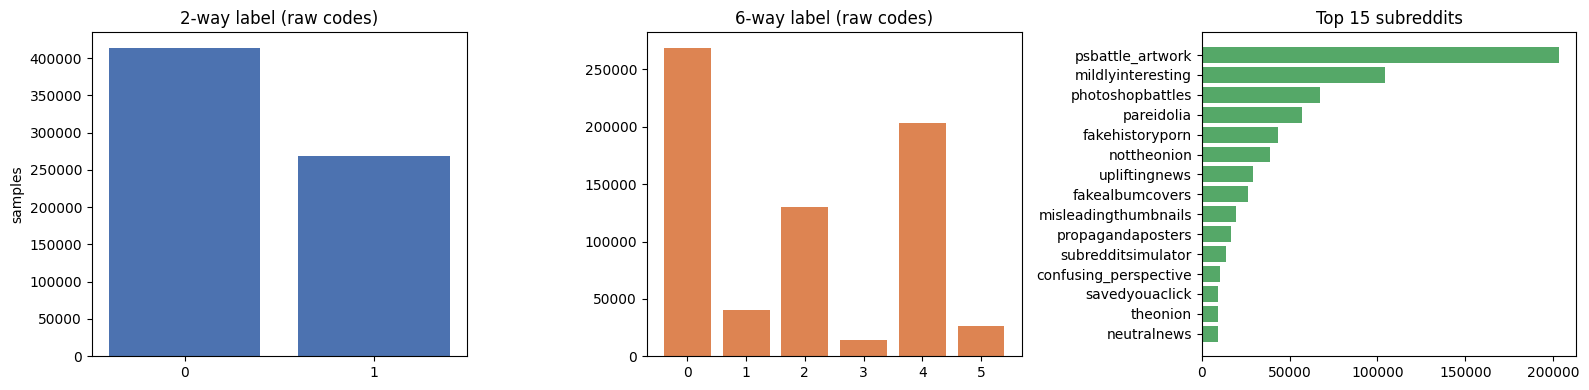

[figure] /content/drive/MyDrive/fake_news_multimodal/results/figures/07_dataset_overview.png


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

vc2 = pool[LABEL2].value_counts().sort_index()
axes[0].bar(vc2.index.astype(str), vc2.values, color="#4C72B0")
axes[0].set_title("2-way label (raw codes)"); axes[0].set_ylabel("samples")

vc6 = pool[LABEL6].value_counts().sort_index()
axes[1].bar(vc6.index.astype(str), vc6.values, color="#DD8452")
axes[1].set_title("6-way label (raw codes)")

top_subs = pool["subreddit"].value_counts().head(15) if "subreddit" in pool.columns else pd.Series(dtype=int)
axes[2].barh(top_subs.index[::-1], top_subs.values[::-1], color="#55A868")
axes[2].set_title("Top 15 subreddits")

savefig("07_dataset_overview.png")

---
# 8. Data Cleaning

Two text columns are kept side by side:

- `original_text` - exactly as published, never modified. Used for error analysis and qualitative inspection.
- `clean_text` - normalised for modelling.

Cleaning is deliberately **conservative**. Case, punctuation and emoji are preserved: CLIP and BLIP-2 were pre-trained on natural web captions, so aggressive lowercasing/stripping moves the input away from the pre-training distribution and destroys signal. Only genuine artefacts are removed - HTML entities, mojibake, bare URLs, Reddit crossposting markers, and whitespace noise.

In [17]:
URL_RE     = re.compile(r"https?://\S+|www\.\S+")
REDDIT_RE  = re.compile(r"\b(?:x-?post(?:ed)?(?:\s+from)?|crosspost(?:ed)?(?:\s+from)?)\b\s*/?r/\w+", re.I)
SUBREF_RE  = re.compile(r"(?<!\w)/?[ru]/[A-Za-z0-9_\-]+")
BRACKET_RE = re.compile(r"^\s*[\[\(](?:oc|mic|nsfw|serious|repost|x-?post)[\]\)]\s*", re.I)
WS_RE      = re.compile(r"\s+")

def clean_text_fn(s):
    if not isinstance(s, str):
        return ""
    t = html.unescape(html.unescape(s))          # double-encoded entities are common in Reddit dumps
    t = unicodedata.normalize("NFKC", t)
    t = t.replace("\u200b", " ").replace("\ufeff", " ")
    t = "".join(ch for ch in t if ch == "\n" or ch == "\t" or unicodedata.category(ch)[0] != "C")
    t = URL_RE.sub(" ", t)
    t = REDDIT_RE.sub(" ", t)
    t = SUBREF_RE.sub(" ", t)
    prev = None
    while prev != t:                              # strip repeated leading tags like "[OC][Serious]"
        prev = t
        t = BRACKET_RE.sub("", t)
    t = WS_RE.sub(" ", t).strip()
    return t

pool["original_text"] = pool[TEXT_COL].astype(str)
pool["clean_text"]    = pool["original_text"].map(clean_text_fn)

empty_after = (pool["clean_text"].str.len() == 0)
print(f"Rows whose text becomes empty after cleaning : {int(empty_after.sum()):,}")
print(f"Median length  original {pool['original_text'].str.len().median():.0f} chars"
      f"  ->  clean {pool['clean_text'].str.len().median():.0f} chars")

demo = pool.loc[pool["original_text"] != pool["clean_text"], ["original_text", "clean_text"]].head(8)
show(demo, 8, "Cleaning examples (original -> clean)")

pool["_has_text"] = pool["clean_text"].str.len() > 0
print(f"\nCandidate pool (clean text AND image_url): {int((pool['_has_text'] & pool['_has_url']).sum()):,}")

Rows whose text becomes empty after cleaning : 0
Median length  original 34 chars  ->  clean 34 chars

=== Cleaning examples (original -> clean) ===
                                                              original_text                                                          clean_text
141733  gen sherman moments after promising former slaves acres and a mule  gen sherman moments after promising former slaves acres and a mule
162678                                             air get to the spacepod                                             air get to the spacepod
410909          protect your family and your barn from the hellfire above           protect your family and your barn from the hellfire above
511537                                 two polar bears sitting in the snow                                 two polar bears sitting in the snow

Candidate pool (clean text AND image_url): 680,798


---
# 9. Image Acquisition and Validation

The proposal notes that a large proportion of Fakeddit image links are dead, so the working dataset is defined by what can actually be retrieved.

**9.1 - Pilot probe.** 500 random URLs are fetched first to measure the real live-image rate. That rate sizes the candidate pool: to end up with `TARGET_N` usable pairs we must attempt roughly `TARGET_N / rate * 1.15`.

**9.2 - Acquisition.** Images are fetched with retries, timeouts, a progress bar and per-URL failure logging. One bad image cannot crash the run - every fetch is wrapped, and failures are recorded with their reason rather than silently dropped.

**Storage.** Each image is decoded, resized (short side to 224) and centre-cropped to 224x224, then re-encoded as JPEG and appended to a single `images.bin` blob with a companion offset index. This matters on Drive: 20,000 individual small files would take longer to *list* than to download, whereas one blob plus an index is a single fast file. All three backbones consume 224x224 input, so nothing is lost.

The MD5 of the stored bytes and the perceptual hash are computed **during** the download, while the image is already decoded, so Section 10 needs no second decode pass.

**Resume.** `image_index.csv` records every attempted sample with its outcome. Re-running this cell retries only `pending` and `error` rows; `ok` and `dead` are skipped.

In [18]:
import requests
from requests.adapters import HTTPAdapter
from scipy.fftpack import dct

IMG_BIN   = DIRS["images"] / "images.bin"
IMG_INDEX = DIRS["images"] / "image_index.csv"
S = CFG["image_size"]

def _phash64(pil_img):
    # 32x32 DCT perceptual hash -> 64-bit int
    g = np.asarray(pil_img.convert("L").resize((32, 32), Image.BILINEAR), dtype=np.float64)
    d = dct(dct(g, axis=0, norm="ortho"), axis=1, norm="ortho")[:8, :8]
    flat = d.flatten()[1:]                       # drop DC term
    bits = flat > np.median(flat)
    out = 0
    for b in bits[:64]:
        out = (out << 1) | int(b)
    return out

def _make_session():
    s = requests.Session()
    s.mount("http://",  HTTPAdapter(pool_maxsize=64, max_retries=CFG["download_retries"]))
    s.mount("https://", HTTPAdapter(pool_maxsize=64, max_retries=CFG["download_retries"]))
    s.headers.update({"User-Agent": "Mozilla/5.0 (academic research; multimodal fake news study)"})
    return s

def fetch_one(sid, url, session):
    # returns (sid, status, jpeg_bytes_or_None, md5, phash, reason)
    try:
        r = session.get(url, timeout=CFG["download_timeout"], stream=True)
        if r.status_code != 200:
            return sid, "dead", None, "", -1, f"http_{r.status_code}"
        raw = r.content
        if len(raw) < 512:
            return sid, "invalid", None, "", -1, "too_small"
        img = Image.open(io.BytesIO(raw))
        img.load()                                # forces full decode; truncated files raise here
        img = img.convert("RGB")
        w, h = img.size
        if min(w, h) < 32:
            return sid, "invalid", None, "", -1, "tiny_dimensions"
        scale = S / min(w, h)
        img = img.resize((max(S, int(round(w*scale))), max(S, int(round(h*scale)))), Image.BICUBIC)
        w, h = img.size
        left, top = (w - S) // 2, (h - S) // 2
        img = img.crop((left, top, left + S, top + S))
        ph = _phash64(img)
        buf = io.BytesIO()
        img.save(buf, format="JPEG", quality=CFG["jpeg_quality"])
        b = buf.getvalue()
        return sid, "ok", b, hashlib.md5(b).hexdigest(), ph, ""
    except requests.exceptions.RequestException as e:
        return sid, "dead", None, "", -1, f"net:{type(e).__name__}"
    except Exception as e:
        return sid, "invalid", None, "", -1, f"decode:{type(e).__name__}"

print("Image helpers ready.")

Image helpers ready.


In [19]:
def run_acquisition(todo_df, index_df):
    # Appends to IMG_BIN and returns an updated index dataframe. Safe to interrupt.
    session = _make_session()
    rows = []
    lock = __import__("threading").Lock()
    offset = IMG_BIN.stat().st_size if IMG_BIN.exists() else 0
    fh = open(IMG_BIN, "ab")
    counts = Counter()
    try:
        with ThreadPoolExecutor(max_workers=CFG["download_workers"]) as ex:
            futs = [ex.submit(fetch_one, sid, url, session)
                    for sid, url in zip(todo_df[ID_COL], todo_df["image_url"])]
            for i, fut in enumerate(tqdm(futs, desc="fetching images")):
                sid, status, b, md5, ph, reason = fut.result()
                counts[status] += 1
                off, ln = -1, 0
                if status == "ok":
                    with lock:
                        fh.write(b); off = offset; ln = len(b); offset += ln
                rows.append({ID_COL: sid, "status": status, "offset": off, "length": ln,
                             "img_md5": md5, "phash": ph, "reason": reason})
                if (i + 1) % 2000 == 0:
                    fh.flush()
                    pd.concat([index_df, pd.DataFrame(rows)], ignore_index=True)\
                      .drop_duplicates(subset=[ID_COL], keep="last").to_csv(IMG_INDEX, index=False)
    finally:
        fh.flush(); fh.close()
    out = pd.concat([index_df, pd.DataFrame(rows)], ignore_index=True)\
            .drop_duplicates(subset=[ID_COL], keep="last")
    out.to_csv(IMG_INDEX, index=False)
    print(dict(counts))
    return out


def read_image_bytes(offset, length):
    with open(IMG_BIN, "rb") as f:
        f.seek(int(offset)); return f.read(int(length))

def read_image(offset, length):
    return Image.open(io.BytesIO(read_image_bytes(offset, length))).convert("RGB")

# ---- 9.1 pilot probe --------------------------------------------------
candidates = pool[pool["_has_text"] & pool["_has_url"]].copy()
candidates = candidates.drop_duplicates(subset=[ID_COL], keep="first").reset_index(drop=True)
print(f"Candidate pool with both modalities: {len(candidates):,}")

RATE_PATH = DIRS["logs"] / "pilot_rate.json"
if RATE_PATH.exists():
    live_rate = json.load(open(RATE_PATH))["live_rate"]
    print(f"[cache HIT ] pilot live-image rate = {live_rate:.3f}")
else:
    probe = candidates.sample(n=min(CFG["pilot_url_probe"], len(candidates)), random_state=SEED)
    sess = _make_session()
    ok = 0
    with ThreadPoolExecutor(max_workers=CFG["download_workers"]) as ex:
        futs = [ex.submit(fetch_one, s, u, sess) for s, u in zip(probe[ID_COL], probe["image_url"])]
        for fut in tqdm(futs, desc="pilot probe"):
            ok += int(fut.result()[1] == "ok")
    live_rate = max(ok / len(probe), 0.05)
    json.dump({"live_rate": live_rate, "probed": len(probe), "ok": ok}, open(RATE_PATH, "w"))
    print(f"Pilot: {ok}/{len(probe)} usable  ->  live rate = {live_rate:.3f}")

need = int(math.ceil(CFG["target_n"] / live_rate * 1.15))
print(f"To reach {CFG['target_n']:,} usable pairs we must attempt about {need:,} URLs.")

Candidate pool with both modalities: 680,798
[cache HIT ] pilot live-image rate = 0.918
To reach 20,000 usable pairs we must attempt about 25,055 URLs.


In [20]:
from pathlib import Path
import pandas as pd

print("DIRS['images'] =", DIRS["images"])

idx = DIRS["images"] / "image_index.csv"
b   = DIRS["images"] / "images.bin"

print("\nimage_index.csv:", "found" if idx.exists() else "MISSING")
print("images.bin     :", f"{b.stat().st_size/2**20:.1f} MB" if b.exists() else "MISSING")

if idx.exists():
    _idx = pd.read_csv(idx)
    print("\n" + _idx["status"].value_counts().to_string())
    print("\nusable (ok):", int((_idx["status"] == "ok").sum()))

DIRS['images'] = /content/drive/MyDrive/fake_news_multimodal/data/images

image_index.csv: found
images.bin     : 373.1 MB

status
ok         23246
dead        1397
invalid      413

usable (ok): 23246


In [21]:
import transformers, peft, torch
print(transformers.__version__, peft.__version__)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NONE")

4.57.6 0.20.0
GPU: NVIDIA A100-SXM4-40GB


In [22]:
import transformers, peft
print("transformers:", transformers.__version__)
print("peft:", peft.__version__)

transformers: 4.57.6
peft: 0.20.0


In [23]:
import shutil
from pathlib import Path

_src = DIRS["images"] / "images.bin"
IMG_BIN = Path("/content/images.bin")
if not IMG_BIN.exists() or IMG_BIN.stat().st_size != _src.stat().st_size:
    shutil.copy(_src, IMG_BIN)
print(f"local image store: {IMG_BIN}  ({IMG_BIN.stat().st_size/2**20:.1f} MB)")

local image store: /content/images.bin  (373.1 MB)


In [24]:
# ---- 9.2 acquisition (class-balanced attempt set) --------------------
# Sample the attempt set balanced on the raw 2-way label. Link death is
# unrelated to label, so a balanced attempt set yields a near-balanced result.
per_class = int(math.ceil(need / candidates[LABEL2].nunique()))
attempt = pd.concat(
    [g.sample(n=min(per_class, len(g)), random_state=SEED)
     for _, g in candidates.groupby(LABEL2, sort=True)],
    ignore_index=True).sample(frac=1.0, random_state=SEED).reset_index(drop=True)
print(f"Attempt set: {len(attempt):,} rows")
print(attempt[LABEL2].value_counts().to_string())

index_df = pd.read_csv(IMG_INDEX) if IMG_INDEX.exists() else \
           pd.DataFrame(columns=[ID_COL, "status", "offset", "length", "img_md5", "phash", "reason"])
if len(index_df):
    index_df[ID_COL] = index_df[ID_COL].astype(str)
attempt[ID_COL] = attempt[ID_COL].astype(str)

done_ok   = set(index_df.loc[index_df["status"].isin(["ok", "dead"]), ID_COL]) if len(index_df) else set()
todo = attempt[~attempt[ID_COL].isin(done_ok)]
print(f"Already resolved: {len(done_ok):,} | still to fetch: {len(todo):,}")

if len(todo):
    index_df = run_acquisition(todo, index_df)
else:
    print("Nothing to fetch - SKIPPING (resume path).")

index_df[ID_COL] = index_df[ID_COL].astype(str)

Attempt set: 25,056 rows
2_way_label
0    12528
1    12528
Already resolved: 24,643 | still to fetch: 413


fetching images:   0%|          | 0/413 [00:00<?, ?it/s]

{'invalid': 413}


In [25]:
# ---- 9.3 validation summary -----------------------------------------
n_ok = int((index_df["status"] == "ok").sum())
summary = pd.DataFrame({
    "metric": ["pooled corpus rows",
               "clean text available",
               "image_url present",
               "both text and image_url (candidates)",
               "image fetch attempted",
               "valid image retrieved",
               "link dead / unreachable",
               "retrieved but corrupt or unusable",
               "BOTH MODALITIES USABLE"],
    "count": [len(pool),
              int(pool["_has_text"].sum()),
              int(pool["_has_url"].sum()),
              len(candidates),
              len(index_df),
              n_ok,
              int((index_df["status"] == "dead").sum()),
              int((index_df["status"] == "invalid").sum()),
              n_ok],
})
print("=== IMAGE VALIDATION SUMMARY ===")
print(summary.to_string(index=False))

print("\nFailure reasons (top 12) - failures are logged, not silently dropped:")
print(index_df.loc[index_df["status"] != "ok", "reason"].value_counts().head(12).to_string())

assert n_ok >= 1000, (f"Only {n_ok} usable images. Re-run the acquisition cell to retry, "
                      "or increase CFG['target_n'] headroom.")

# Working dataset = pooled metadata joined to successfully stored images
ok_idx = index_df[index_df["status"] == "ok"].copy()
pool[ID_COL] = pool[ID_COL].astype(str)
work = pool.merge(ok_idx[[ID_COL, "offset", "length", "img_md5", "phash"]], on=ID_COL, how="inner")
work = work.drop_duplicates(subset=[ID_COL], keep="first").reset_index(drop=True)
print(f"\nWorking dataset (text + verified image): {len(work):,} rows")
print(work[LABEL2].value_counts().to_string())

=== IMAGE VALIDATION SUMMARY ===
                              metric  count
                  pooled corpus rows 682661
                clean text available 682661
                   image_url present 680798
both text and image_url (candidates) 680798
               image fetch attempted  25056
               valid image retrieved  23246
             link dead / unreachable   1397
   retrieved but corrupt or unusable    413
              BOTH MODALITIES USABLE  23246

Failure reasons (top 12) - failures are logged, not silently dropped:
reason
http_404                         1358
too_small                         400
net:ConnectionError                18
decode:UnidentifiedImageError      10
http_502                            6
http_403                            5
http_504                            5
tiny_dimensions                     3
http_402                            2
http_500                            2
http_400                            1

Working dataset (text + verifi

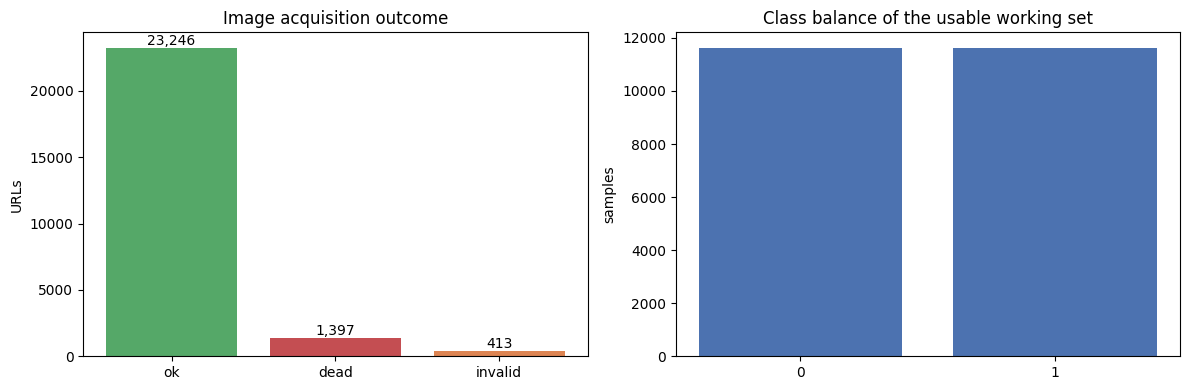

[figure] /content/drive/MyDrive/fake_news_multimodal/results/figures/09_image_acquisition.png


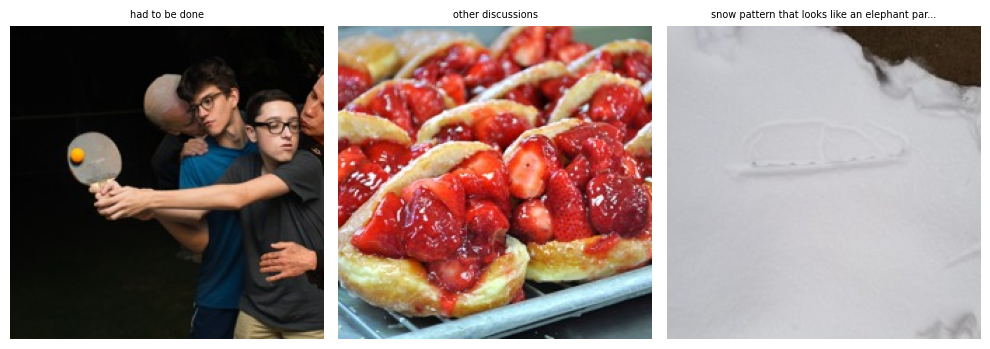

[figure] /content/drive/MyDrive/fake_news_multimodal/results/figures/09_stored_image_examples.png


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sc = index_df["status"].value_counts()
axes[0].bar(sc.index, sc.values, color=["#55A868", "#C44E52", "#DD8452"][:len(sc)])
axes[0].set_title("Image acquisition outcome"); axes[0].set_ylabel("URLs")
for i, v in enumerate(sc.values): axes[0].text(i, v, f"{v:,}", ha="center", va="bottom")

wc = work[LABEL2].value_counts().sort_index()
axes[1].bar(wc.index.astype(str), wc.values, color="#4C72B0")
axes[1].set_title("Class balance of the usable working set"); axes[1].set_ylabel("samples")
savefig("09_image_acquisition.png")

# visual sanity check on three stored images
sample3 = work.sample(3, random_state=SEED)
fig, axs = plt.subplots(1, 3, figsize=(10, 3.6))
for ax, (_, r) in zip(axs, sample3.iterrows()):
    ax.imshow(read_image(r["offset"], r["length"])); ax.axis("off")
    ax.set_title(r["clean_text"][:44] + ("..." if len(r["clean_text"]) > 44 else ""), fontsize=7)
savefig("09_stored_image_examples.png")

---
# 10. Duplicate Detection

The same content is reposted across Fakeddit's twenty subreddits. If a repost lands in train and its twin in test, the reported score is inflated. The purpose here is **not** state-of-the-art deduplication - it is to build `group_id` so that Section 12 can keep whole families of near-identical items inside one split.

Four signals, merged with union-find:

| Signal | Method | Cost |
|---|---|---|
| Exact text | SHA-1 of casefolded, punctuation-stripped text | O(n) |
| Exact image | MD5 of the stored JPEG bytes (computed in Section 9) | free |
| Near-duplicate text | MinHash + LSH banding, 128 permutations, 16 bands, char 5-gram shingles, Jaccard >= 0.80 | ~seconds |
| Near-duplicate image | Perceptual hash (computed in Section 9), Hamming <= 6, pigeonhole banding | ~seconds |

LSH banding is used rather than all-pairs comparison, which would be 200M+ comparisons at this scale.

In [27]:
class UnionFind:
    def __init__(self, n): self.p = list(range(n)); self.r = [0]*n
    def find(self, x):
        while self.p[x] != x:
            self.p[x] = self.p[self.p[x]]; x = self.p[x]
        return x
    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra == rb: return False
        if self.r[ra] < self.r[rb]: ra, rb = rb, ra
        self.p[rb] = ra
        if self.r[ra] == self.r[rb]: self.r[ra] += 1
        return True

PUNCT_RE = re.compile(r"[^\w\s]", re.UNICODE)
def norm_for_dup(t):
    return WS_RE.sub(" ", PUNCT_RE.sub(" ", t.casefold())).strip()

def shingles(t, k):
    t = norm_for_dup(t)
    if len(t) < k: return {t} if t else set()
    return {t[i:i+k] for i in range(len(t) - k + 1)}

def minhash_signatures(sets, n_perm, seed=SEED):
    MOD = (1 << 61) - 1
    rs = np.random.RandomState(seed)
    a = rs.randint(1, MOD, size=n_perm, dtype=np.int64)
    b = rs.randint(0, MOD, size=n_perm, dtype=np.int64)
    sig = np.full((len(sets), n_perm), np.iinfo(np.int64).max, dtype=np.int64)
    for i, s in enumerate(tqdm(sets, desc="minhash", leave=False)):
        if not s: continue
        h = np.fromiter((int(hashlib.blake2b(x.encode("utf8"), digest_size=8).hexdigest(), 16) % MOD
                         for x in s), dtype=np.int64, count=len(s))
        vals = (np.multiply.outer(h, a) + b) % MOD          # |s| x n_perm
        sig[i] = vals.min(axis=0)
    return sig

def lsh_candidates(sig, n_bands):
    n, n_perm = sig.shape
    rows = n_perm // n_bands
    pairs = set()
    for bi in range(n_bands):
        buckets = defaultdict(list)
        band = sig[:, bi*rows:(bi+1)*rows]
        for i in range(n):
            buckets[band[i].tobytes()].append(i)
        for members in buckets.values():
            if 1 < len(members) <= 200:           # ignore degenerate mega-buckets (e.g. empty text)
                for x in range(len(members)):
                    for y in range(x+1, len(members)):
                        pairs.add((members[x], members[y]))
    return pairs

def phash_candidates(hashes, max_ham):
    n_bands = max_ham + 1
    width = 64 // n_bands
    pairs = set()
    for bi in range(n_bands):
        shift = bi * width
        mask = ((1 << width) - 1) << shift
        buckets = defaultdict(list)
        for i, h in enumerate(hashes):
            if h < 0: continue
            buckets[(h & mask) >> shift].append(i)
        for members in buckets.values():
            if 1 < len(members) <= 200:
                for x in range(len(members)):
                    for y in range(x+1, len(members)):
                        pairs.add((members[x], members[y]))
    return pairs

print("Duplicate-detection helpers ready.")

Duplicate-detection helpers ready.


In [28]:
GROUPS_PATH = DIRS["processed"] / "grouped.parquet"

def build_groups():
    df = work.reset_index(drop=True).copy()
    n = len(df)
    uf = UnionFind(n)
    stats = {}

    # 1. exact text
    tex = df["clean_text"].map(lambda t: hashlib.sha1(norm_for_dup(t).encode("utf8")).hexdigest())
    df["text_hash"] = tex
    linked = 0
    for _, idxs in tex.groupby(tex).groups.items():
        idxs = list(idxs)
        for j in idxs[1:]:
            linked += uf.union(idxs[0], j)
    stats["exact_text_links"] = linked

    # 2. exact image
    linked = 0
    for _, idxs in df.groupby("img_md5").groups.items():
        idxs = list(idxs)
        for j in idxs[1:]:
            linked += uf.union(idxs[0], j)
    stats["exact_image_links"] = linked

    # 3. near-duplicate text
    sets = [shingles(t, CFG["shingle_k"]) for t in df["clean_text"]]
    sig = minhash_signatures(sets, CFG["minhash_perms"])
    cand = lsh_candidates(sig, CFG["minhash_bands"])
    stats["text_lsh_candidate_pairs"] = len(cand)
    linked = 0
    for i, j in cand:
        si, sj = sets[i], sets[j]
        if not si or not sj: continue
        inter = len(si & sj)
        if inter and inter / (len(si) + len(sj) - inter) >= CFG["jaccard_threshold"]:
            linked += uf.union(i, j)
    stats["near_text_links"] = linked

    # 4. near-duplicate image
    ph = df["phash"].astype(np.int64).tolist()
    cand = phash_candidates(ph, CFG["phash_hamming_threshold"])
    stats["image_band_candidate_pairs"] = len(cand)
    linked = 0
    for i, j in cand:
        if bin(ph[i] ^ ph[j]).count("1") <= CFG["phash_hamming_threshold"]:
            linked += uf.union(i, j)
    stats["near_image_links"] = linked

    roots = [uf.find(i) for i in range(n)]
    remap = {r: g for g, r in enumerate(sorted(set(roots)))}
    df["group_id"] = [remap[r] for r in roots]
    stats["n_samples"] = n
    stats["n_groups"] = df["group_id"].nunique()
    json.dump(stats, open(DIRS["logs"] / "duplicate_stats.json", "w"), indent=2)
    print(json.dumps(stats, indent=2))
    return df

grouped = cache_df(GROUPS_PATH, build_groups)

gsz = grouped.groupby("group_id").size()
print(f"\n{len(grouped):,} samples -> {grouped['group_id'].nunique():,} groups")
print(f"Singleton groups: {int((gsz == 1).sum()):,} | largest group: {int(gsz.max())} samples")
print(f"Samples absorbed into multi-item groups: {int(gsz[gsz > 1].sum()):,}")

[cache HIT ] grouped.parquet

23,246 samples -> 21,980 groups
Singleton groups: 21,585 | largest group: 253 samples
Samples absorbed into multi-item groups: 1,661


---
# 11. Label Preparation

Fakeddit ships 2-way, 3-way and 6-way labels. The proposal's primary task is binary, with the six-way scheme retained for error analysis.

**Polarity is verified empirically rather than assumed.** In the six-way scheme, one class is genuine news and the other five are falsehood types. Whichever 2-way code co-occurs with that single class is therefore "true". The crosstab below prints the evidence; the mapping is derived from it, not hard-coded.

The modelling target is set so that **positive = FAKE**. This matters: F1 is the proposal's primary metric and is asymmetric, so it must be measured on the class the system exists to catch.

In [29]:
ct = pd.crosstab(grouped[LABEL6], grouped[LABEL2])
print("=== 6-way x 2-way crosstab (polarity evidence) ===")
print(ct.to_string())

# The genuine class is the 6-way code that maps to exactly one 2-way code
# and is the ONLY 6-way code doing so from that side.
purity = ct.div(ct.sum(axis=1), axis=0)
mapped = purity.idxmax(axis=1)
counts_per_2way = Counter(mapped.values)
true_code_2way = [c for c, k in counts_per_2way.items() if k == 1]
assert len(true_code_2way) == 1, (
    f"Could not resolve polarity unambiguously: {counts_per_2way}. Inspect the crosstab above.")
TRUE_CODE = true_code_2way[0]
TRUE_6WAY = mapped[mapped == TRUE_CODE].index.tolist()

print(f"\nResolved: 2_way_label == {TRUE_CODE} is TRUE news "
      f"(it is the exclusive partner of 6-way class {TRUE_6WAY}).")
print(f"          2_way_label != {TRUE_CODE} is FAKE (the five falsehood categories).")

if "subreddit" in grouped.columns:
    print("\nCorroboration - top subreddits per resolved class:")
    for code_, name in [(TRUE_CODE, "TRUE"), (1 - TRUE_CODE, "FAKE")]:
        top = grouped.loc[grouped[LABEL2] == code_, "subreddit"].value_counts().head(5)
        print(f"  {name:<5}: {', '.join(f'{i} ({v:,})' for i, v in top.items())}")

grouped["label"] = (grouped[LABEL2] != TRUE_CODE).astype(int)   # 1 = FAKE (positive class)
grouped["label_name"] = grouped["label"].map({0: "true", 1: "fake"})

print("\n=== FINAL BINARY LABEL (1 = FAKE = positive class) ===")
vc = grouped["label"].value_counts().sort_index()
print(pd.DataFrame({"count": vc, "pct": (vc/len(grouped)*100).round(2)}).to_string())
print("\n=== 6-way distribution (retained for error analysis) ===")
print(grouped[LABEL6].value_counts().sort_index().to_string())

json.dump({"true_2way_code": int(TRUE_CODE), "true_6way_codes": [int(x) for x in TRUE_6WAY],
           "positive_class": "fake", "crosstab": ct.to_dict()},
          open(DIRS["logs"] / "label_mapping.json", "w"), indent=2, default=str)

=== 6-way x 2-way crosstab (polarity evidence) ===
2_way_label     0      1
6_way_label             
0               0  11616
1            1100      0
2            3566      0
3             428      0
4            5793      0
5             743      0

Resolved: 2_way_label == 1 is TRUE news (it is the exclusive partner of 6-way class [0]).
          2_way_label != 1 is FAKE (the five falsehood categories).

Corroboration - top subreddits per resolved class:
  TRUE : mildlyinteresting (4,324), photoshopbattles (2,895), nottheonion (1,752), upliftingnews (1,338), neutralnews (393)
  FAKE : psbattle_artwork (5,793), pareidolia (1,610), fakehistoryporn (1,160), fakealbumcovers (678), misleadingthumbnails (542)

=== FINAL BINARY LABEL (1 = FAKE = positive class) ===
       count    pct
label              
0      11616  49.97
1      11630  50.03

=== 6-way distribution (retained for error analysis) ===
6_way_label
0    11616
1     1100
2     3566
3      428
4     5793
5      743


---
# 12. Train / Validation / Test Split

**This split is created once and never regenerated.** Every model in this notebook reads the same three CSVs.

Procedure:

1. Collapse to groups. A group's label is its majority label (near-identical items essentially always agree).
2. Balance at group level to reach `TARGET_N`, so class balance is not achieved by cutting a group in half.
3. Shuffle groups within each class stratum with the fixed seed, then assign **whole groups** to train/val/test by cumulative sample count until 70/15/15 is reached.

Assigning whole groups is what makes the split leak-proof; stratifying within class is what keeps the three sets comparable.

In [30]:
SPLIT_FILES = {s: DIRS["splits"] / f"{s}.csv" for s in ["train", "validation", "test"]}

def build_split():
    g = (grouped.groupby("group_id")
         .agg(n=("label", "size"), label=("label", lambda s: int(s.mode().iat[0])))
         .reset_index())

    per_class_target = CFG["target_n"] // 2
    chosen = []
    for lab in [0, 1]:
        sub = g[g["label"] == lab].sample(frac=1.0, random_state=SEED).reset_index(drop=True)
        cum = sub["n"].cumsum()
        n_keep = int((cum <= per_class_target).sum())
        if n_keep < len(sub):
            n_keep += 1                            # one group of overshoot beats undershooting
        keep = sub.iloc[:max(n_keep, 1)]
        chosen.append(keep)
        print(f"  class {lab}: {len(keep):,} groups -> {int(keep['n'].sum()):,} samples "
              f"(target {per_class_target:,}; available {int(sub['n'].sum()):,})")
    sel = pd.concat(chosen, ignore_index=True)

    assign = {}
    for lab in [0, 1]:
        sub = sel[sel["label"] == lab].sample(frac=1.0, random_state=SEED + 1 + lab).reset_index(drop=True)
        total = sub["n"].sum()
        b_tr = CFG["split_train"] * total
        b_va = (CFG["split_train"] + CFG["split_val"]) * total
        run = 0
        for _, r in sub.iterrows():
            assign[r["group_id"]] = "train" if run < b_tr else ("validation" if run < b_va else "test")
            run += r["n"]

    df = grouped[grouped["group_id"].isin(assign)].copy()
    df["split"] = df["group_id"].map(assign)
    return df.reset_index(drop=True)

if all(p.exists() for p in SPLIT_FILES.values()):
    print("Official split already exists on Drive - LOADING (never regenerated).")
    parts = {s: pd.read_csv(p, low_memory=False) for s, p in SPLIT_FILES.items()}
    for s in parts: parts[s][ID_COL] = parts[s][ID_COL].astype(str)
else:
    print("Creating the ONE official split...")
    split_df = build_split()
    keep_cols = [ID_COL, "clean_text", "original_text", "offset", "length", "img_md5", "phash",
                 "text_hash", "group_id", "label", "label_name", LABEL2, LABEL6, "split"]
    if "subreddit" in split_df.columns: keep_cols.append("subreddit")
    keep_cols = [c for c in keep_cols if c in split_df.columns]
    split_df = split_df[keep_cols]
    parts = {s: split_df[split_df["split"] == s].reset_index(drop=True) for s in SPLIT_FILES}
    for s, p in SPLIT_FILES.items():
        parts[s].to_csv(p, index=False)
        print(f"  wrote {p.name}: {len(parts[s]):,} rows")

train_df, val_df, test_df = parts["train"], parts["validation"], parts["test"]

tbl = pd.DataFrame([{
    "split": s, "samples": len(d), "pct": round(len(d)/sum(len(x) for x in parts.values())*100, 2),
    "groups": d["group_id"].nunique(),
    "fake": int((d["label"] == 1).sum()), "true": int((d["label"] == 0).sum()),
    "fake_pct": round((d["label"] == 1).mean()*100, 2)} for s, d in parts.items()])
print("\n=== OFFICIAL SPLIT ===")
print(tbl.to_string(index=False))

Official split already exists on Drive - LOADING (never regenerated).

=== OFFICIAL SPLIT ===
     split  samples  pct  groups  fake  true  fake_pct
     train    14002 70.0   12978  7011  6991     50.07
validation     3000 15.0    2941  1502  1498     50.07
      test     3000 15.0    2918  1502  1498     50.07


---
# 13. Data Leakage Check

A hard gate. Twelve checks - four overlap types across three split pairs. **Any failure raises `RuntimeError` and stops the notebook** before a single model is trained. A warning would be useless here; the whole point is that the run cannot proceed on a compromised split.

In [31]:
def leakage_gate(parts):
    pairs = [("train", "validation"), ("train", "test"), ("validation", "test")]
    keys = {"sample_id": ID_COL, "group_id": "group_id",
            "text_hash": "text_hash", "image_md5": "img_md5"}
    rows, failures = [], []
    for a, b in pairs:
        for kname, col in keys.items():
            if col not in parts[a].columns:
                rows.append({"pair": f"{a} vs {b}", "check": kname, "overlap": "SKIPPED (no column)",
                             "status": "SKIP"}); continue
            ov = set(parts[a][col].astype(str)) & set(parts[b][col].astype(str))
            ok = len(ov) == 0
            rows.append({"pair": f"{a} vs {b}", "check": kname, "overlap": len(ov),
                         "status": "PASS" if ok else "FAIL"})
            if not ok:
                failures.append(f"{kname} overlap between {a} and {b}: {len(ov)} shared values "
                                f"(examples: {list(ov)[:5]})")
    report = pd.DataFrame(rows)
    print("=== LEAKAGE GATE ===")
    print(report.to_string(index=False))
    report.to_csv(DIRS["metrics"] / "leakage_report.csv", index=False)
    if failures:
        raise RuntimeError("LEAKAGE DETECTED - PIPELINE STOPPED.\n" + "\n".join(failures))
    print(f"\nAll {len(report)} checks passed. Safe to train.")
    return report

leakage_report = leakage_gate(parts)

TEST_LOCKED = True
print("\nTest set is now LOCKED. It is not read again until Section 19.")

=== LEAKAGE GATE ===
               pair     check  overlap status
train vs validation sample_id        0   PASS
train vs validation  group_id        0   PASS
train vs validation text_hash        0   PASS
train vs validation image_md5        0   PASS
      train vs test sample_id        0   PASS
      train vs test  group_id        0   PASS
      train vs test text_hash        0   PASS
      train vs test image_md5        0   PASS
 validation vs test sample_id        0   PASS
 validation vs test  group_id        0   PASS
 validation vs test text_hash        0   PASS
 validation vs test image_md5        0   PASS

All 12 checks passed. Safe to train.

Test set is now LOCKED. It is not read again until Section 19.


---
## Shared machinery for Sections 14-19

Three things every model section needs: a way to stream stored images through a frozen backbone, a standard metric block, and a standard lightweight-head trainer. Defining them once keeps CLIP and BLIP-2 on a **matched footing** - the proposal requires that RQ2 compare *representations*, not classifier designs, so both use an identical head, optimiser, schedule and seed set.

In [32]:
ALL_SPLITS = {"train": train_df, "validation": val_df, "test": test_df}
SPLIT_ORDER = ["train", "validation", "test"]
ALL_DF = pd.concat([ALL_SPLITS[s].assign(split=s) for s in SPLIT_ORDER], ignore_index=True)
print({s: len(d) for s, d in ALL_SPLITS.items()})

class StoredImageDataset(torch.utils.data.Dataset):
    def __init__(self, df, transform=None):
        self.off = df["offset"].to_numpy()
        self.len_ = df["length"].to_numpy()
        self.transform = transform
    def __len__(self): return len(self.off)
    def __getitem__(self, i):
        img = read_image(self.off[i], self.len_[i])
        return self.transform(img) if self.transform is not None else img

def pil_collate(batch): return batch

def image_loader(df, batch_size, transform=None, workers=2):
    return torch.utils.data.DataLoader(
        StoredImageDataset(df, transform), batch_size=batch_size, shuffle=False,
        num_workers=workers, collate_fn=None if transform is not None else pil_collate)

# ---- metrics ---------------------------------------------------------
def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (np.asarray(y_prob) >= threshold).astype(int)
    m = {
        "accuracy":  float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall":    float(recall_score(y_true, y_pred, zero_division=0)),
        "f1":        float(f1_score(y_true, y_pred, zero_division=0)),
        "threshold": float(threshold),
        "pred_positive_rate": float(y_pred.mean()),
    }
    try:
        m["auc_roc"] = float(roc_auc_score(y_true, y_prob))
        m["auc_pr"]  = float(average_precision_score(y_true, y_prob))
    except ValueError:
        m["auc_roc"] = float("nan"); m["auc_pr"] = float("nan")
    return m

def pick_threshold(y_true, y_prob):
    # F1-optimal threshold on VALIDATION only, with a degeneracy guard:
    # when signal is weak the F1-optimal point collapses to "predict all fake",
    # which looks fine on F1 and is useless. Fall back to 0.5 in that case.
    prec, rec, thr = precision_recall_curve(y_true, y_prob)
    f1 = np.divide(2*prec*rec, prec+rec, out=np.zeros_like(prec), where=(prec+rec) > 0)
    best = int(np.nanargmax(f1[:-1])) if len(thr) else 0
    t = float(thr[best]) if len(thr) else 0.5
    if (np.asarray(y_prob) >= t).mean() > 0.95:
        print("  [guard] F1-optimal threshold predicts >95% positive - falling back to 0.50")
        return 0.5
    return t

PREDICTORS = {}   # name -> dict(prob_fn(split)->np.array, threshold, cost)
print("Shared machinery ready.")

{'train': 14002, 'validation': 3000, 'test': 3000}
Shared machinery ready.


In [33]:
# ---- standard lightweight classification head ------------------------
class Head(nn.Module):
    def __init__(self, in_dim, hidden, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(in_dim),
            nn.Linear(in_dim, hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden // 2, 1))
    def forward(self, x): return self.net(x).squeeze(-1)

def _tensor_loader(X, y, bs, shuffle, seed=SEED):
    ds = torch.utils.data.TensorDataset(torch.from_numpy(X).float(),
                                        torch.from_numpy(y).float())
    g = torch.Generator(); g.manual_seed(seed)
    return torch.utils.data.DataLoader(ds, batch_size=bs, shuffle=shuffle, generator=g)

def train_head(Xtr, ytr, Xva, yva, seed, tag, verbose=True):
    # Early stopping on validation AUC - threshold-free, so model selection
    # never depends on a decision threshold we have not chosen yet.
    seed_everything(seed)
    model = Head(Xtr.shape[1], CFG["head_hidden"], CFG["head_dropout"]).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=CFG["head_lr"],
                            weight_decay=CFG["head_weight_decay"])
    lossf = nn.BCEWithLogitsLoss()
    tl = _tensor_loader(Xtr, ytr, CFG["batch"]["head"], True, seed)
    Xva_t = torch.from_numpy(Xva).float().to(DEVICE)

    best_auc, best_state, bad, history = -1.0, None, 0, []
    t0 = time.time()
    for epoch in range(1, CFG["head_max_epochs"] + 1):
        model.train(); tot = 0.0
        for xb, yb in tl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = lossf(model(xb), yb)
            loss.backward(); opt.step()
            tot += loss.item() * len(xb)
        model.eval()
        with torch.no_grad():
            pv = torch.sigmoid(model(Xva_t)).cpu().numpy()
        auc = roc_auc_score(yva, pv)
        history.append({"epoch": epoch, "train_loss": tot/len(Xtr), "val_auc": float(auc)})
        if verbose:
            print(f"    epoch {epoch:>2}  loss {tot/len(Xtr):.4f}  val AUC {auc:.4f}"
                  + ("  *" if auc > best_auc else ""))
        if auc > best_auc:
            best_auc, bad = auc, 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= CFG["head_patience"]:
                if verbose: print(f"    early stop at epoch {epoch}")
                break
    model.load_state_dict(best_state)             # BEST epoch, not last
    model.eval()
    return model, {"tag": tag, "seed": seed, "best_val_auc": float(best_auc),
                   "epochs_run": len(history), "train_seconds": round(time.time()-t0, 1),
                   "history": history,
                   "trainable_params": int(sum(p.numel() for p in model.parameters()))}

@torch.no_grad()
def head_predict(model, X, bs=4096):
    model.eval(); out = []
    for i in range(0, len(X), bs):
        xb = torch.from_numpy(X[i:i+bs]).float().to(DEVICE)
        out.append(torch.sigmoid(model(xb)).cpu().numpy())
    return np.concatenate(out) if out else np.array([])

def train_head_multiseed(feats, y, name, ckpt_name):
    Xtr, Xva = feats["train"], feats["validation"]
    ytr, yva = y["train"], y["validation"]
    runs, models = [], []
    for s in CFG["head_seeds"]:
        print(f"  --- {name} seed {s} ---")
        m, info = train_head(Xtr, ytr, Xva, yva, s, name, verbose=(s == CFG["head_seeds"][0]))
        runs.append(info); models.append(m)
    aucs = np.array([r["best_val_auc"] for r in runs])
    print(f"\n  {name}: val AUC across {len(aucs)} seeds = {aucs.mean():.4f} +/- {aucs.std(ddof=1):.4f}")
    best_i = int(np.argmax(aucs))
    best = models[best_i]
    torch.save({"state_dict": best.state_dict(), "in_dim": Xtr.shape[1],
                "hidden": CFG["head_hidden"], "dropout": CFG["head_dropout"],
                "seed": CFG["head_seeds"][best_i], "runs": runs},
               DIRS["checkpoints"] / ckpt_name)
    return best, runs, {"val_auc_mean": float(aucs.mean()), "val_auc_sd": float(aucs.std(ddof=1)),
                        "n_seeds": len(aucs), "seconds": float(sum(r["train_seconds"] for r in runs))}

def oof_head_predictions(feats, y, folds=CFG["cv_folds"]):
    # Out-of-fold predictions on TRAIN, used by the Section 18 stacking meta-learner.
    Xtr, ytr = feats["train"], y["train"]
    oof = np.zeros(len(ytr))
    skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=SEED)
    for k, (ti, vi) in enumerate(skf.split(Xtr, ytr), 1):
        m, _ = train_head(Xtr[ti], ytr[ti], Xtr[vi], ytr[vi], SEED, f"oof{k}", verbose=False)
        oof[vi] = head_predict(m, Xtr[vi])
        del m; free_gpu()
    print(f"  OOF train AUC: {roc_auc_score(ytr, oof):.4f}")
    return oof

Y = {s: ALL_SPLITS[s]["label"].to_numpy().astype(int) for s in SPLIT_ORDER}
print("Head trainer ready.")

Head trainer ready.


---
# 14. Traditional Multimodal Baselines (RQ1)

The proposal's traditional pipeline is deliberately **late fusion of independently encoded modalities** - that is the paradigm RQ1 tests against jointly pre-trained VLMs, so the design is not a weakness to be optimised away.

- **Text:** TF-IDF (word 1-2 grams), reduced with Truncated SVD to 256 dimensions.
- **Image:** frozen ResNet-50 (`IMAGENET1K_V2`), penultimate 2048-d pooled features. Never trained.
- **Fusion:** concatenation, each block standardised.
- **Classifiers:** Logistic Regression, Decision Tree, Random Forest, XGBoost, KNN, tuned by k-fold cross-validation **on the training split only**.

**Every preprocessing step is fitted on train and merely applied to validation and test.** Positive evidence of this is printed below rather than asserted in a comment.

In [34]:
RESNET_CACHE = DIRS["embeddings"] / "resnet50_features.npz"

def extract_resnet():
    from torchvision.models import resnet50
    w = getattr(torchvision.models.ResNet50_Weights, CFG["resnet_weights"])
    net = resnet50(weights=w)
    n_params = sum(p.numel() for p in net.parameters())
    net.fc = nn.Identity()                        # feature extractor only - never trained
    net = net.to(DEVICE).eval()
    for p in net.parameters(): p.requires_grad_(False)
    tf = w.transforms()
    print(f"  ResNet-50 {CFG['resnet_weights']} | {n_params/1e6:.1f}M params | frozen | {DEVICE}")

    out = {}
    for s in SPLIT_ORDER:
        dl = image_loader(ALL_SPLITS[s], CFG["batch"]["resnet"], transform=tf)
        feats = []
        with torch.no_grad():
            for xb in tqdm(dl, desc=f"resnet:{s}", leave=False):
                xb = xb.to(DEVICE, non_blocking=True)
                with torch.autocast("cuda", dtype=AMP_DTYPE, enabled=USE_AMP):
                    f = net(xb)
                feats.append(f.float().cpu().numpy())
        out[s] = np.concatenate(feats)
        print(f"    {s:<11} {out[s].shape}")
    del net; free_gpu()
    return out

resnet_feats = cache_npz(RESNET_CACHE, extract_resnet)
for s in SPLIT_ORDER:
    assert len(resnet_feats[s]) == len(ALL_SPLITS[s]), f"ResNet feature/row mismatch on {s}"
print("ResNet-50 features aligned with the official split.")

[cache HIT ] resnet50_features.npz
ResNet-50 features aligned with the official split.


In [35]:
# ---- TF-IDF fitted on TRAIN ONLY -------------------------------------
tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1, 2), min_df=2,
                        sublinear_tf=True, strip_accents="unicode")
Xtr_txt = tfidf.fit_transform(train_df["clean_text"])            # FIT on train
Xva_txt = tfidf.transform(val_df["clean_text"])                  # transform only
Xte_txt = tfidf.transform(test_df["clean_text"])                 # transform only

svd = TruncatedSVD(n_components=256, random_state=SEED)
Ttr = svd.fit_transform(Xtr_txt)                                 # FIT on train
Tva, Tte = svd.transform(Xva_txt), svd.transform(Xte_txt)

sc_txt, sc_img = StandardScaler(), StandardScaler()
Ttr = sc_txt.fit_transform(Ttr); Tva = sc_txt.transform(Tva); Tte = sc_txt.transform(Tte)
Itr = sc_img.fit_transform(resnet_feats["train"])
Iva = sc_img.transform(resnet_feats["validation"]); Ite = sc_img.transform(resnet_feats["test"])

TRAD = {"train": np.hstack([Ttr, Itr]).astype(np.float32),
        "validation": np.hstack([Tva, Iva]).astype(np.float32),
        "test": np.hstack([Tte, Ite]).astype(np.float32)}

print("=== POSITIVE EVIDENCE THAT PREPROCESSING WAS FITTED ON TRAIN ONLY ===")
print(f"  TF-IDF vocabulary size            : {len(tfidf.vocabulary_):,}")
print(f"  TF-IDF fitted on n documents      : {Xtr_txt.shape[0]:,}  (== len(train) {len(train_df):,})")
print(f"  SVD explained variance (train)    : {svd.explained_variance_ratio_.sum():.4f}")
print(f"  Scaler n_samples_seen_ (text)     : {sc_txt.n_samples_seen_:,}")
print(f"  Scaler n_samples_seen_ (image)    : {sc_img.n_samples_seen_:,}")
print(f"  -> all equal len(train), so no validation/test row influenced any fit.")
print(f"\n  Validation mean of train-fitted text scaler: {Tva.mean():+.4f} "
      f"(non-zero by construction - it would be ~0 if we had wrongly refitted)")
for s in SPLIT_ORDER: print(f"  fused {s:<11} {TRAD[s].shape}")

=== POSITIVE EVIDENCE THAT PREPROCESSING WAS FITTED ON TRAIN ONLY ===
  TF-IDF vocabulary size            : 15,768
  TF-IDF fitted on n documents      : 14,002  (== len(train) 14,002)
  SVD explained variance (train)    : 0.2410
  Scaler n_samples_seen_ (text)     : 14,002
  Scaler n_samples_seen_ (image)    : 14,002
  -> all equal len(train), so no validation/test row influenced any fit.

  Validation mean of train-fitted text scaler: -0.0003 (non-zero by construction - it would be ~0 if we had wrongly refitted)
  fused train       (14002, 2304)
  fused validation  (3000, 2304)
  fused test        (3000, 2304)


In [36]:
from xgboost import XGBClassifier

TRAD_GRIDS = {
    "LogisticRegression": (LogisticRegression(max_iter=2000, random_state=SEED),
                           {"C": [0.1, 1.0, 5.0]}),
    "DecisionTree":       (DecisionTreeClassifier(random_state=SEED),
                           {"max_depth": [8, 16, None], "min_samples_leaf": [1, 10]}),
    "RandomForest":       (RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=SEED),
                           {"max_depth": [16, None], "min_samples_leaf": [1, 5]}),
    "XGBoost":            (XGBClassifier(n_estimators=400, learning_rate=0.1, max_depth=6,
                                         subsample=0.9, colsample_bytree=0.8, n_jobs=-1,
                                         tree_method="hist", eval_metric="logloss",
                                         random_state=SEED),
                           {"max_depth": [4, 6], "learning_rate": [0.05, 0.1]}),
    "KNN":                (KNeighborsClassifier(n_jobs=-1),
                           {"n_neighbors": [15, 35], "weights": ["distance"]}),
}

TRAD_PATH = DIRS["metrics"] / "traditional_results.json"
trad_models, trad_summary, trad_oof = {}, [], {}

SKIPPED_TRAD = []
for name, (est, grid) in TRAD_GRIDS.items():
    print(f"\n=== {name} ===")
    t0 = time.time()
    try:
        gs = GridSearchCV(est, grid, scoring="f1", cv=CFG["cv_folds"], n_jobs=1, refit=True)
        gs.fit(TRAD["train"], Y["train"])         # k-fold CV on TRAIN ONLY
    except Exception as exc:
        # Most likely cause is an xgboost/scikit-learn version mismatch. One broken
        # classifier must not destroy the run; it is reported as NOT YET EXECUTED.
        print(f"  SKIPPED - {type(exc).__name__}: {exc}")
        SKIPPED_TRAD.append(name)
        continue
    fit_s = time.time() - t0
    best = gs.best_estimator_
    trad_models[name] = best

    pv = best.predict_proba(TRAD["validation"])[:, 1]
    thr = pick_threshold(Y["validation"], pv)
    m = compute_metrics(Y["validation"], pv, thr)
    print(f"  best params : {gs.best_params_}")
    print(f"  CV F1 (train, {CFG['cv_folds']}-fold): {gs.best_score_:.4f}")
    print(f"  VALIDATION  : F1 {m['f1']:.4f} | AUC {m['auc_roc']:.4f} | acc {m['accuracy']:.4f}")

    trad_oof[name] = cross_val_predict(best, TRAD["train"], Y["train"],
                                       cv=StratifiedKFold(CFG["cv_folds"], shuffle=True,
                                                          random_state=SEED),
                                       method="predict_proba", n_jobs=1)[:, 1]
    trad_summary.append({"model": name, "cv_f1_train": float(gs.best_score_),
                         "val_f1": m["f1"], "val_auc": m["auc_roc"], "val_acc": m["accuracy"],
                         "threshold": thr, "fit_seconds": round(fit_s, 1),
                         "best_params": gs.best_params_})
    record(name, "validation", m)
    PREDICTORS[name] = {"prob": (lambda mdl: (lambda s: mdl.predict_proba(TRAD[s])[:, 1]))(best),
                        "threshold": thr, "family": "traditional",
                        "cost_seconds": round(fit_s, 1)}

assert trad_summary, "Every traditional classifier failed to fit - cannot continue."
if SKIPPED_TRAD:
    print(f"\nNOT YET EXECUTED (fit failed): {SKIPPED_TRAD}")
trad_tbl = pd.DataFrame(trad_summary).sort_values("val_auc", ascending=False)
print("\n=== TRADITIONAL BASELINES - VALIDATION (RQ1 reference points) ===")
print(trad_tbl.drop(columns=["best_params"]).to_string(index=False))
json.dump(trad_summary, open(TRAD_PATH, "w"), indent=2, default=str)

BEST_TRAD = trad_tbl.iloc[0]["model"]
print(f"\nStrongest traditional model on validation: {BEST_TRAD}")


=== LogisticRegression ===
  best params : {'C': 0.1}
  CV F1 (train, 5-fold): 0.7411
  VALIDATION  : F1 0.7641 | AUC 0.8310 | acc 0.7417

=== DecisionTree ===
  [guard] F1-optimal threshold predicts >95% positive - falling back to 0.50
  best params : {'max_depth': 16, 'min_samples_leaf': 1}
  CV F1 (train, 5-fold): 0.6525
  VALIDATION  : F1 0.6454 | AUC 0.6138 | acc 0.6623

=== RandomForest ===
  best params : {'max_depth': None, 'min_samples_leaf': 1}
  CV F1 (train, 5-fold): 0.7372
  VALIDATION  : F1 0.7658 | AUC 0.8416 | acc 0.7427

=== XGBoost ===
  best params : {'learning_rate': 0.1, 'max_depth': 6}
  CV F1 (train, 5-fold): 0.7950
  VALIDATION  : F1 0.8080 | AUC 0.8823 | acc 0.7957

=== KNN ===
  best params : {'n_neighbors': 15, 'weights': 'distance'}
  CV F1 (train, 5-fold): 0.6405
  VALIDATION  : F1 0.6870 | AUC 0.6926 | acc 0.5683

=== TRADITIONAL BASELINES - VALIDATION (RQ1 reference points) ===
             model  cv_f1_train   val_f1  val_auc  val_acc  threshold  fit_se

---
# 15. CLIP (RQ2)

CLIP is used as a **frozen** dual encoder. The backbone is never updated here; only a lightweight head is trained.

Following the proposal, the head receives *both* a joint representation and an explicit cross-modal agreement score:

`[ image_emb (512) | text_emb (512) | image*text (512) | |image - text| (512) | cosine (1) ] = 2049 dims`

The element-wise product and absolute difference are standard interaction terms - they let a linear layer express agreement per dimension rather than only through the single scalar cosine. The scalar is kept because the proposal names it explicitly.

Before any classifier is trained, the cell after extraction reports cosine similarity **descriptively** by class and by six-way category. That is direct evidence for RQ2's premise - that genuine pairs are more semantically coherent than fake ones - independent of whatever the classifier later does.

In [37]:
# =====================================================================
# SECTION 15 - CLIP extraction, self-healing
# Rebuilds any global this kernel has lost, from what is on Drive.
# Existing globals are never overwritten.
# =====================================================================
import os, io, gc, json, math, random, hashlib, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from tqdm.auto import tqdm
from transformers import CLIPModel, CLIPProcessor

warnings.filterwarnings("ignore", category=UserWarning)
_restored = []

# ---- 1. project directories ------------------------------------------
if "DIRS" not in globals():
    try:
        from google.colab import drive
        drive.mount("/content/drive")
    except Exception as _e:
        print(f"[warn] could not mount Drive automatically: {_e}")

    PROJECT_ROOT = Path("/content/drive/MyDrive/fake_news_multimodal")
    DIRS = {
        "raw":         PROJECT_ROOT / "data" / "raw",
        "processed":   PROJECT_ROOT / "data" / "processed",
        "images":      PROJECT_ROOT / "data" / "images",
        "splits":      PROJECT_ROOT / "data" / "splits",
        "checkpoints": PROJECT_ROOT / "models" / "checkpoints",
        "cached":      PROJECT_ROOT / "models" / "cached_models",
        "embeddings":  PROJECT_ROOT / "embeddings",
        "metrics":     PROJECT_ROOT / "results" / "metrics",
        "figures":     PROJECT_ROOT / "results" / "figures",
        "predictions": PROJECT_ROOT / "results" / "predictions",
        "logs":        PROJECT_ROOT / "logs",
    }
    for _p in DIRS.values():
        _p.mkdir(parents=True, exist_ok=True)
    _LOCAL_CACHE = Path("/content/hf_cache")
    _LOCAL_CACHE.mkdir(parents=True, exist_ok=True)
    os.environ["HF_HOME"] = str(_LOCAL_CACHE)
    _restored.append("DIRS")

# ---- 2. locate the image store and the split CSVs --------------------
def _locate():
    img, spl = None, None
    if (DIRS["images"] / "images.bin").exists():
        img = DIRS["images"] / "images.bin"
    if (DIRS["splits"] / "train.csv").exists():
        spl = DIRS["splits"]
    if img is None or spl is None:
        for root in (Path("/content/drive/MyDrive"), Path("/content"), Path.cwd()):
            if not root.exists():
                continue
            if img is None:
                for p in root.rglob("images.bin"):
                    img = p; break
            if spl is None:
                for p in root.rglob("train.csv"):
                    if (p.parent / "validation.csv").exists() and (p.parent / "test.csv").exists():
                        spl = p.parent; break
    return img, spl

IMG_BIN_FOUND, SPLIT_DIR = _locate()
if IMG_BIN_FOUND is None or SPLIT_DIR is None:
    raise FileNotFoundError(
        f"images.bin={IMG_BIN_FOUND}  splits={SPLIT_DIR}\n"
        "Neither the image store nor the split CSVs were found on Drive. "
        "Re-run the notebook from Section 6. If images.bin survived on Drive, "
        "the acquisition step will resume rather than re-download."
    )
if "IMG_BIN" not in globals():
    IMG_BIN = IMG_BIN_FOUND
    _restored.append("IMG_BIN")
print(f"images.bin : {IMG_BIN_FOUND}  ({IMG_BIN_FOUND.stat().st_size/2**20:.0f} MB)")
print(f"splits     : {SPLIT_DIR}")

# ---- 3. hardware and precision ---------------------------------------
if "DEVICE" not in globals():
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    _restored.append("DEVICE")
if "USE_AMP" not in globals():
    USE_AMP = torch.cuda.is_available()
    _restored.append("USE_AMP")
if "AMP_DTYPE" not in globals():
    AMP_DTYPE = torch.float16 if torch.cuda.is_available() else torch.float32
    _restored.append("AMP_DTYPE")

_vram = round(torch.cuda.get_device_properties(0).total_memory / 2**30, 2) \
        if torch.cuda.is_available() else 0.0
if   _vram >= 22: _BATCH = {"resnet":128, "clip":256, "blip2":32, "head":1024, "lora":64}
elif _vram >= 14: _BATCH = {"resnet": 64, "clip":128, "blip2":16, "head":1024, "lora":32}
elif _vram >=  9: _BATCH = {"resnet": 32, "clip": 64, "blip2": 8, "head": 512, "lora":16}
elif _vram >   0: _BATCH = {"resnet": 16, "clip": 32, "blip2": 4, "head": 512, "lora": 8}
else:             _BATCH = {"resnet": 16, "clip": 16, "blip2": 2, "head": 256, "lora": 4}

# ---- 4. config -------------------------------------------------------
if "CFG" not in globals():
    CFG = {
        "seed": 42, "image_size": 224, "target_n": 20000,
        "clip_model": "openai/clip-vit-base-patch32",
        "blip2_model": "Salesforce/blip2-itm-vit-g",
        "resnet_weights": "IMAGENET1K_V2",
        "split_train": 0.70, "split_val": 0.15, "split_test": 0.15,
        "head_hidden": 512, "head_dropout": 0.3,
        "head_lr": 1e-3, "head_weight_decay": 1e-4,
        "head_max_epochs": 15, "head_patience": 3, "head_seeds": [42, 43, 44],
        "run_lora": True, "lora_r": 8, "lora_alpha": 16, "lora_dropout": 0.05,
        "lora_lr": 1e-4, "lora_epochs": 3, "lora_patience": 1,
        "cv_folds": 5,
    }
    _restored.append("CFG")
CFG.setdefault("batch", _BATCH)

if "SEED" not in globals():
    SEED = CFG["seed"]
    random.seed(SEED); np.random.seed(SEED)
    os.environ["PYTHONHASHSEED"] = str(SEED)
    torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False
    _restored.append("SEED")

# ---- 5. utilities ----------------------------------------------------
if "cache_npz" not in globals():
    def cache_npz(path, build_fn, force=False):
        path = Path(path)
        if path.exists() and not force:
            print(f"[cache HIT ] {path.name}")
            with np.load(path, allow_pickle=True) as z:
                return {k: z[k] for k in z.files}
        print(f"[cache MISS] {path.name} - computing...")
        out = build_fn()
        np.savez_compressed(path, **out)
        print(f"[cache SAVE] {path.name}  ({path.stat().st_size/2**20:.1f} MB)")
        return out
    _restored.append("cache_npz")

if "free_gpu" not in globals():
    def free_gpu():
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache(); torch.cuda.synchronize()
    _restored.append("free_gpu")

if "RESULTS" not in globals():
    RESULTS = {}
    def record(model, split, metrics):
        RESULTS.setdefault(model, {})[split] = metrics
        with open(DIRS["metrics"] / "results.json", "w") as f:
            json.dump(RESULTS, f, indent=2, default=float)
    _restored.append("RESULTS")

# ---- 6. image store readers ------------------------------------------
if "read_image" not in globals():
    def read_image_bytes(offset, length):
        with open(IMG_BIN, "rb") as f:
            f.seek(int(offset)); return f.read(int(length))
    def read_image(offset, length):
        return Image.open(io.BytesIO(read_image_bytes(offset, length))).convert("RGB")
    _restored.append("read_image")

if "StoredImageDataset" not in globals():
    class StoredImageDataset(torch.utils.data.Dataset):
        def __init__(self, df, transform=None):
            self.off = df["offset"].to_numpy()
            self.len_ = df["length"].to_numpy()
            self.transform = transform
        def __len__(self): return len(self.off)
        def __getitem__(self, i):
            img = read_image(self.off[i], self.len_[i])
            return self.transform(img) if self.transform is not None else img
    _restored.append("StoredImageDataset")

if "pil_collate" not in globals():
    def pil_collate(batch): return batch

if "image_loader" not in globals():
    def image_loader(df, batch_size, transform=None, workers=2):
        return torch.utils.data.DataLoader(
            StoredImageDataset(df, transform), batch_size=batch_size, shuffle=False,
            num_workers=workers, collate_fn=None if transform is not None else pil_collate)
    _restored.append("image_loader")

# ---- 7. the one official split ---------------------------------------
if "ALL_SPLITS" not in globals():
    train_df = pd.read_csv(SPLIT_DIR / "train.csv", low_memory=False)
    val_df   = pd.read_csv(SPLIT_DIR / "validation.csv", low_memory=False)
    test_df  = pd.read_csv(SPLIT_DIR / "test.csv", low_memory=False)
    for _d in (train_df, val_df, test_df):
        _d["clean_text"] = _d["clean_text"].fillna("").astype(str)
    ALL_SPLITS = {"train": train_df, "validation": val_df, "test": test_df}
    _restored.append("ALL_SPLITS")

if "SPLIT_ORDER" not in globals():
    SPLIT_ORDER = ["train", "validation", "test"]
    _restored.append("SPLIT_ORDER")

if "ALL_DF" not in globals():
    ALL_DF = pd.concat([ALL_SPLITS[s].assign(split=s) for s in SPLIT_ORDER],
                       ignore_index=True)
    _restored.append("ALL_DF")

if "Y" not in globals():
    Y = {s: ALL_SPLITS[s]["label"].to_numpy().astype(int) for s in SPLIT_ORDER}
    _restored.append("Y")

if "ID_COL" not in globals():
    ID_COL = "id" if "id" in ALL_SPLITS["train"].columns else ALL_SPLITS["train"].columns[0]
    LABEL2, LABEL3, LABEL6 = "2_way_label", "3_way_label", "6_way_label"
    _restored.append("ID_COL")

print(f"[restored] {', '.join(_restored) if _restored else 'nothing - kernel state intact'}")
print({s: len(d) for s, d in ALL_SPLITS.items()})
_r = ALL_SPLITS["train"].iloc[0]
print(f"image store OK - first train image {read_image(_r['offset'], _r['length']).size}")

# ---- 8. CLIP extraction ----------------------------------------------
CLIP_CACHE = DIRS["embeddings"] / "clip_embeddings.npz"

# T4 is SM 7.5 - bf16 there is emulated and slow, so force fp16 on pre-Ampere
if torch.cuda.is_available() and torch.cuda.get_device_capability(0)[0] < 8:
    CLIP_DTYPE = torch.float16
else:
    CLIP_DTYPE = AMP_DTYPE if USE_AMP else torch.float32

def extract_clip():
    proc  = CLIPProcessor.from_pretrained(CFG["clip_model"])
    model = CLIPModel.from_pretrained(CFG["clip_model"], torch_dtype=CLIP_DTYPE)
    model = model.to(DEVICE).eval()
    for p in model.parameters():
        p.requires_grad_(False)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"  Model        : {CFG['clip_model']}")
    print(f"  Source       : Hugging Face Hub (cached at {os.environ.get('HF_HOME')})")
    print(f"  Parameters   : {n_params/1e6:.1f}M | FROZEN | device {DEVICE} | dtype {model.dtype}")

    out, trunc_total = {}, 0
    for s in SPLIT_ORDER:
        df    = ALL_SPLITS[s]
        texts = df["clean_text"].fillna("").astype(str).tolist()
        ie, te = [], []
        dl = image_loader(df, CFG["batch"]["clip"], transform=None)
        cursor = 0
        for pil_batch in tqdm(dl, desc=f"clip:{s}", leave=False):
            chunk = texts[cursor:cursor + len(pil_batch)]; cursor += len(pil_batch)
            tok = proc.tokenizer(chunk, padding="max_length", truncation=True,
                                 max_length=77, return_tensors="pt")
            raw = proc.tokenizer(chunk, padding=False, truncation=False)["input_ids"]
            trunc_total += int(sum(len(r) > 77 for r in raw))
            px = proc.image_processor(images=pil_batch, return_tensors="pt")["pixel_values"]
            with torch.no_grad():
                i = model.get_image_features(pixel_values=px.to(DEVICE, dtype=model.dtype))
                t = model.get_text_features(input_ids=tok["input_ids"].to(DEVICE),
                                            attention_mask=tok["attention_mask"].to(DEVICE))
            ie.append(i.float().cpu().numpy()); te.append(t.float().cpu().numpy())
        out[f"{s}_image"] = np.concatenate(ie)
        out[f"{s}_text"]  = np.concatenate(te)
        print(f"    {s:<11} image {out[f'{s}_image'].shape}  text {out[f'{s}_text'].shape}")
    out["n_truncated_texts"] = np.array([trunc_total])
    del model; free_gpu()
    return out

clip_emb = cache_npz(CLIP_CACHE, extract_clip)
print(f"\nTexts exceeding CLIP's 77-token limit: {int(clip_emb['n_truncated_texts'][0]):,} "
      f"of {len(ALL_DF):,} ({int(clip_emb['n_truncated_texts'][0])/len(ALL_DF)*100:.2f}%)")

images.bin : /content/drive/MyDrive/fake_news_multimodal/data/images/images.bin  (373 MB)
splits     : /content/drive/MyDrive/fake_news_multimodal/data/splits
[restored] nothing - kernel state intact
{'train': 14002, 'validation': 3000, 'test': 3000}
image store OK - first train image (224, 224)
[cache HIT ] clip_embeddings.npz

Texts exceeding CLIP's 77-token limit: 0 of 20,002 (0.00%)


CLIP head input dimension: 2049  (= 4 x 512 + 1)

=== CLIP image-text cosine similarity by class ===
class     n   mean    sd
 true  9987 0.2961 0.042
 fake 10015 0.2467 0.049
Cohen's d (true - fake) = +1.0816

=== CLIP cosine by six-way category ===
 6way    n  mean_cos     sd  is_true_class
    0 9987    0.2961 0.0420           True
    1  951    0.2822 0.0511          False
    2 3012    0.2541 0.0471          False
    3  365    0.2006 0.0418          False
    4 5033    0.2331 0.0408          False
    5  654    0.2918 0.0479          False


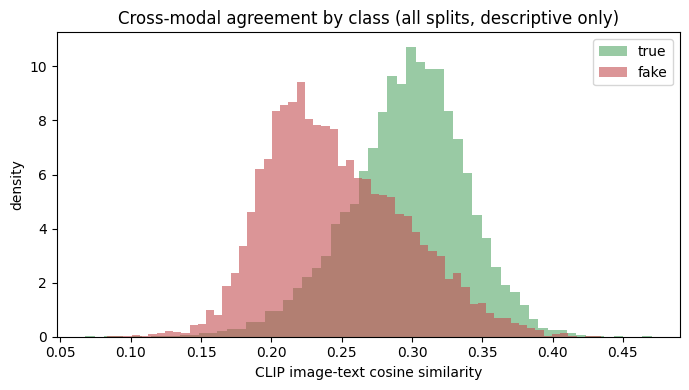

[figure] /content/drive/MyDrive/fake_news_multimodal/results/figures/15_clip_cosine_by_class.png


In [38]:
def l2n(a): return a / np.clip(np.linalg.norm(a, axis=1, keepdims=True), 1e-8, None)

CLIP_FEATS, CLIP_COS = {}, {}
for s in SPLIT_ORDER:
    i, t = l2n(clip_emb[f"{s}_image"]), l2n(clip_emb[f"{s}_text"])
    cos = (i * t).sum(1, keepdims=True)
    CLIP_COS[s] = cos.ravel()
    CLIP_FEATS[s] = np.hstack([i, t, i*t, np.abs(i-t), cos]).astype(np.float32)
CLIP_DIM = CLIP_FEATS["train"].shape[1]
print(f"CLIP head input dimension: {CLIP_DIM}  (= 4 x 512 + 1)")

# ---- descriptive RQ2 evidence, before any classifier -------------------
cos_all = np.concatenate([CLIP_COS[s] for s in SPLIT_ORDER])
lab_all = np.concatenate([Y[s] for s in SPLIT_ORDER])
six_all = ALL_DF[LABEL6].to_numpy()

def cohens_d(a, b):
    na, nb = len(a), len(b)
    sp = math.sqrt(((na-1)*a.var(ddof=1) + (nb-1)*b.var(ddof=1)) / max(na+nb-2, 1))
    return (a.mean() - b.mean()) / sp if sp > 0 else 0.0

ct_ = cos_all[lab_all == 0]; cf_ = cos_all[lab_all == 1]
print("\n=== CLIP image-text cosine similarity by class ===")
print(pd.DataFrame({"class": ["true", "fake"], "n": [len(ct_), len(cf_)],
                    "mean": [ct_.mean(), cf_.mean()], "sd": [ct_.std(ddof=1), cf_.std(ddof=1)]}
                   ).round(4).to_string(index=False))
print(f"Cohen's d (true - fake) = {cohens_d(ct_, cf_):+.4f}")

rows = []
for c in sorted(pd.unique(six_all)):
    v = cos_all[six_all == c]
    rows.append({"6way": c, "n": len(v), "mean_cos": round(float(v.mean()), 4),
                 "sd": round(float(v.std(ddof=1)), 4), "is_true_class": bool(c in TRUE_6WAY)})
print("\n=== CLIP cosine by six-way category ===")
print(pd.DataFrame(rows).to_string(index=False))

plt.figure(figsize=(7, 4))
plt.hist(ct_, bins=60, alpha=0.6, label="true", density=True, color="#55A868")
plt.hist(cf_, bins=60, alpha=0.6, label="fake", density=True, color="#C44E52")
plt.xlabel("CLIP image-text cosine similarity"); plt.ylabel("density"); plt.legend()
plt.title("Cross-modal agreement by class (all splits, descriptive only)")
savefig("15_clip_cosine_by_class.png")

In [39]:
print("=== CLIP head - multi-seed training (frozen backbone) ===")
clip_head, clip_runs, clip_stats = train_head_multiseed(CLIP_FEATS, Y, "CLIP", "clip_head.pt")

pv = head_predict(clip_head, CLIP_FEATS["validation"])
CLIP_THR = pick_threshold(Y["validation"], pv)
m = compute_metrics(Y["validation"], pv, CLIP_THR)
print(f"\nCLIP VALIDATION: F1 {m['f1']:.4f} | AUC {m['auc_roc']:.4f} | acc {m['accuracy']:.4f}")
record("CLIP", "validation", m)

PREDICTORS["CLIP"] = {"prob": lambda s: head_predict(clip_head, CLIP_FEATS[s]),
                      "threshold": CLIP_THR, "family": "vlm",
                      "cost_seconds": clip_stats["seconds"],
                      "val_auc_sd": clip_stats["val_auc_sd"]}

print("\n=== CLIP representation ablation (validation AUC, seed 42) ===")
abl = {"cosine only": [-1], "image only": list(range(0, 512)),
       "text only": list(range(512, 1024)), "image+text": list(range(0, 1024)),
       "full (used)": list(range(CLIP_DIM))}
abl_rows = []
for nm, cols in abl.items():
    F = {s: CLIP_FEATS[s][:, cols] for s in SPLIT_ORDER}
    mm, info = train_head(F["train"], Y["train"], F["validation"], Y["validation"],
                          SEED, nm, verbose=False)
    abl_rows.append({"representation": nm, "dims": len(cols),
                     "val_auc": round(info["best_val_auc"], 4)})
    del mm; free_gpu()
print(pd.DataFrame(abl_rows).to_string(index=False))
pd.DataFrame(abl_rows).to_csv(DIRS["metrics"] / "clip_ablation.csv", index=False)

print("\nComputing CLIP out-of-fold train predictions for stacking...")
CLIP_OOF = oof_head_predictions(CLIP_FEATS, Y)

=== CLIP head - multi-seed training (frozen backbone) ===
  --- CLIP seed 42 ---
    epoch  1  loss 0.4652  val AUC 0.9337  *
    epoch  2  loss 0.3180  val AUC 0.9455  *
    epoch  3  loss 0.2698  val AUC 0.9518  *
    epoch  4  loss 0.2479  val AUC 0.9551  *
    epoch  5  loss 0.2258  val AUC 0.9552  *
    epoch  6  loss 0.1872  val AUC 0.9578  *
    epoch  7  loss 0.1595  val AUC 0.9584  *
    epoch  8  loss 0.1156  val AUC 0.9592  *
    epoch  9  loss 0.0814  val AUC 0.9597  *
    epoch 10  loss 0.0527  val AUC 0.9585
    epoch 11  loss 0.0281  val AUC 0.9591
    epoch 12  loss 0.0171  val AUC 0.9594
    early stop at epoch 12
  --- CLIP seed 43 ---
  --- CLIP seed 44 ---

  CLIP: val AUC across 3 seeds = 0.9603 +/- 0.0006

CLIP VALIDATION: F1 0.9021 | AUC 0.9609 | acc 0.9017

=== CLIP representation ablation (validation AUC, seed 42) ===
representation  dims  val_auc
   cosine only     1   0.5000
    image only   512   0.9055
     text only   512   0.9329
    image+text  1024   0.

---
# 16. BLIP-2 (RQ2)

**BLIP-2's API is not CLIP's, so the representation is chosen from the model's actual outputs rather than assumed.** The next cell loads the model and prints the real shape of every candidate tensor before anything is extracted.

**Checkpoint choice.** `Salesforce/blip2-itm-vit-g` is used because the proposal requires BLIP-2's *image-text matching score* as its agreement signal. The OPT captioning checkpoints have no ITM head and could not supply it.

**Two agreement signals are kept, not one:**

- **ITC** - dual-encoder contrastive similarity, the structural analogue of CLIP's cosine. Cheap.
- **ITM** - the joint-attention matching probability, where text tokens cross-attend the image inside the Q-Former. More expensive, more expressive.

Reporting both, and their correlation, is itself a cost/benefit finding for the proposal's performance-versus-cost theme.

**Matched footing.** The head, optimiser, schedule and seed set are identical to Section 15. Only the input representation differs, so an RQ2 difference is attributable to the representation.

`32 x 256` query embeddings are mean-pooled to `256` so BLIP-2's per-modality width is comparable to CLIP's, giving `4 x 256 + 2 = 1026` dims.

In [40]:
from transformers import Blip2ForImageTextRetrieval, AutoProcessor

BLIP2_CACHE = DIRS["embeddings"] / "blip2_embeddings.npz"

def load_blip2():
    proc = AutoProcessor.from_pretrained(CFG["blip2_model"])
    model = Blip2ForImageTextRetrieval.from_pretrained(
        CFG["blip2_model"], torch_dtype=AMP_DTYPE if USE_AMP else torch.float32,
        low_cpu_mem_usage=True)
    model = model.to(DEVICE).eval()
    for p in model.parameters(): p.requires_grad_(False)
    print(f"  Model      : {CFG['blip2_model']}")
    print(f"  Source     : Hugging Face Hub (cached at {DIRS['cached']})")
    print(f"  Parameters : {sum(p.numel() for p in model.parameters())/1e6:.1f}M | FROZEN")
    print(f"  Device     : {DEVICE} | dtype {model.dtype}")
    return proc, model

# Attribute names differ between transformers versions.
# 4.57+ uses: vision_projection, text_projection
# 4.45-4.56 uses: vision_proj, text_proj
def _get_projections(model):
    vp = getattr(model, "vision_projection", None) or getattr(model, "vision_proj", None)
    tp = getattr(model, "text_projection", None) or getattr(model, "text_proj", None)
    assert vp is not None and tp is not None, "Could not find projection layers on the model"
    return vp, tp

@torch.no_grad()
def blip2_batch(model, px, ids, am):
    # One vision pass, three cheap Q-Former passes.
    B = px.shape[0]
    vision_proj, text_proj = _get_projections(model)

    img_hidden = model.vision_model(pixel_values=px, return_dict=True).last_hidden_state
    img_atts = torch.ones(img_hidden.shape[:-1], dtype=torch.long, device=px.device)
    q = model.query_tokens.expand(B, -1, -1)

    # ITC - image side
    qe = model.embeddings(query_embeds=q)
    qo = model.qformer(query_embeds=qe, encoder_hidden_states=img_hidden,
                       encoder_attention_mask=img_atts, return_dict=True).last_hidden_state
    img_feat = torch.nn.functional.normalize(vision_proj(qo), dim=-1)              # (B,32,256)

    # ITC - text side
    te = model.embeddings(input_ids=ids)
    to = model.qformer(query_embeds=te, query_length=0, attention_mask=am,
                       return_dict=True).last_hidden_state
    txt_feat = torch.nn.functional.normalize(text_proj(to[:, 0, :]), dim=-1)       # (B,256)

    itc = torch.einsum("bqd,bd->bq", img_feat, txt_feat).max(dim=1).values          # (B,)

    # ITM - joint attention
    qam = torch.ones(q.shape[:-1], dtype=torch.long, device=px.device)
    qe2 = model.embeddings(input_ids=ids, query_embeds=q)
    o2 = model.qformer(query_embeds=qe2, query_length=q.shape[1],
                       attention_mask=torch.cat([qam, am], dim=1),
                       encoder_hidden_states=img_hidden, encoder_attention_mask=img_atts,
                       return_dict=True).last_hidden_state
    itm_logits = model.itm_head(o2[:, :q.shape[1], :]).mean(dim=1)                  # (B,2)
    itm = torch.softmax(itm_logits.float(), dim=-1)[:, 1]

    return (img_feat.mean(dim=1).float(), txt_feat.float(), itc.float(), itm)

# ---- REQUIRED: inspect real output shapes before choosing a representation
proc_b2, model_b2 = load_blip2()

# Verify all required submodules exist (with version-tolerant naming)
CORE_ATTRS = ["vision_model", "qformer", "embeddings", "query_tokens", "itm_head"]
_missing = [a for a in CORE_ATTRS if not hasattr(model_b2, a)]
assert not _missing, f"Missing core attributes: {_missing}"

_vp, _tp = _get_projections(model_b2)
print(f"Submodule preflight passed.")
print(f"  Using projection layers: "
      f"vision={'vision_projection' if hasattr(model_b2, 'vision_projection') else 'vision_proj'}, "
      f"text={'text_projection' if hasattr(model_b2, 'text_projection') else 'text_proj'}")

_df = ALL_SPLITS["train"].head(2)
_imgs = [read_image(r["offset"], r["length"]) for _, r in _df.iterrows()]
_tok = proc_b2.tokenizer(_df["clean_text"].tolist(), padding="max_length", truncation=True,
                        max_length=64, return_tensors="pt")
_px = proc_b2.image_processor(images=_imgs, return_tensors="pt")["pixel_values"]
_vis = model_b2.vision_model(pixel_values=_px.to(DEVICE, dtype=model_b2.dtype),
                            return_dict=True).last_hidden_state
print("\n=== LIVE BLIP-2 OUTPUT INSPECTION (shapes are measured, not assumed) ===")
print(f"  vision_model.last_hidden_state : {tuple(_vis.shape)}")
print(f"  query_tokens                   : {tuple(model_b2.query_tokens.shape)}")
_i, _t, _itc, _itm = blip2_batch(model_b2, _px.to(DEVICE, dtype=model_b2.dtype),
                                _tok["input_ids"].to(DEVICE), _tok["attention_mask"].to(DEVICE))
print(f"  pooled image feature           : {tuple(_i.shape)}")
print(f"  text feature                   : {tuple(_t.shape)}")
print(f"  ITC score (contrastive)        : {tuple(_itc.shape)}  e.g. {_itc[0].item():.4f}")
print(f"  ITM score P(match)             : {tuple(_itm.shape)}  e.g. {_itm[0].item():.4f}")
print(f"\n  -> chosen representation: 4 x {_i.shape[1]} + 2 = {4*_i.shape[1] + 2} dims")
del _vis, _i, _t, _itc, _itm; free_gpu()

preprocessor_config.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/21.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/263 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


config.json:   0%|          | 0.00/554 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/4.69G [00:00<?, ?B/s]

  Model      : Salesforce/blip2-itm-vit-g
  Source     : Hugging Face Hub (cached at /content/drive/MyDrive/fake_news_multimodal/models/cached_models)
  Parameters : 1172.0M | FROZEN
  Device     : cuda | dtype torch.bfloat16
Submodule preflight passed.
  Using projection layers: vision=vision_projection, text=text_projection

=== LIVE BLIP-2 OUTPUT INSPECTION (shapes are measured, not assumed) ===
  vision_model.last_hidden_state : (2, 257, 1408)
  query_tokens                   : (1, 32, 768)
  pooled image feature           : (2, 256)
  text feature                   : (2, 256)
  ITC score (contrastive)        : (2,)  e.g. 0.3633
  ITM score P(match)             : (2,)  e.g. 0.3082

  -> chosen representation: 4 x 256 + 2 = 1026 dims


In [41]:
def extract_blip2():
    out = {}
    for s in SPLIT_ORDER:
        df = ALL_SPLITS[s]
        texts = df["clean_text"].tolist()
        I, T, C, M = [], [], [], []
        dl = image_loader(df, CFG["batch"]["blip2"], transform=None, workers=2)
        cursor = 0
        for pil_batch in tqdm(dl, desc=f"blip2:{s}", leave=False):
            chunk = texts[cursor:cursor+len(pil_batch)]; cursor += len(pil_batch)
            tok = proc_b2.tokenizer(chunk, padding="max_length", truncation=True,
                                    max_length=64, return_tensors="pt")
            px = proc_b2.image_processor(images=pil_batch, return_tensors="pt")["pixel_values"]
            i, t, c, m = blip2_batch(model_b2, px.to(DEVICE, dtype=model_b2.dtype),
                                     tok["input_ids"].to(DEVICE),
                                     tok["attention_mask"].to(DEVICE))
            I.append(i.cpu().numpy()); T.append(t.cpu().numpy())
            C.append(c.cpu().numpy()); M.append(m.cpu().numpy())
        out[f"{s}_image"] = np.concatenate(I); out[f"{s}_text"] = np.concatenate(T)
        out[f"{s}_itc"] = np.concatenate(C);   out[f"{s}_itm"] = np.concatenate(M)
        print(f"    {s:<11} image {out[f'{s}_image'].shape}  itc {out[f'{s}_itc'].shape}")
    return out

blip2_emb = cache_npz(BLIP2_CACHE, extract_blip2)
del model_b2; free_gpu()

BLIP2_FEATS = {}
for s in SPLIT_ORDER:
    i, t = l2n(blip2_emb[f"{s}_image"]), l2n(blip2_emb[f"{s}_text"])
    itc = blip2_emb[f"{s}_itc"].reshape(-1, 1); itm = blip2_emb[f"{s}_itm"].reshape(-1, 1)
    BLIP2_FEATS[s] = np.hstack([i, t, i*t, np.abs(i-t), itc, itm]).astype(np.float32)
BLIP2_DIM = BLIP2_FEATS["train"].shape[1]
print(f"\nBLIP-2 head input dimension: {BLIP2_DIM}")

itc_all = np.concatenate([blip2_emb[f"{s}_itc"] for s in SPLIT_ORDER])
itm_all = np.concatenate([blip2_emb[f"{s}_itm"] for s in SPLIT_ORDER])
print(f"\nCorrelation between the two agreement signals: "
      f"Pearson r = {np.corrcoef(itc_all, itm_all)[0,1]:+.4f}")
print("(If r were near 1.0 the expensive joint-attention pass would add nothing over the cheap one.)")
print("\n=== BLIP-2 agreement signals by class ===")
print(pd.DataFrame({
    "signal": ["ITC (contrastive)", "ITC (contrastive)", "ITM P(match)", "ITM P(match)"],
    "class": ["true", "fake", "true", "fake"],
    "mean": [itc_all[lab_all==0].mean(), itc_all[lab_all==1].mean(),
             itm_all[lab_all==0].mean(), itm_all[lab_all==1].mean()],
    "sd":   [itc_all[lab_all==0].std(ddof=1), itc_all[lab_all==1].std(ddof=1),
             itm_all[lab_all==0].std(ddof=1), itm_all[lab_all==1].std(ddof=1)],
}).round(4).to_string(index=False))
print(f"Cohen's d  ITC {cohens_d(itc_all[lab_all==0], itc_all[lab_all==1]):+.4f}"
      f" | ITM {cohens_d(itm_all[lab_all==0], itm_all[lab_all==1]):+.4f}")

[cache HIT ] blip2_embeddings.npz

BLIP-2 head input dimension: 1026

Correlation between the two agreement signals: Pearson r = +0.8684
(If r were near 1.0 the expensive joint-attention pass would add nothing over the cheap one.)

=== BLIP-2 agreement signals by class ===
           signal class   mean     sd
ITC (contrastive)  true 0.3718 0.0808
ITC (contrastive)  fake 0.2589 0.1109
     ITM P(match)  true 0.6865 0.3702
     ITM P(match)  fake 0.3251 0.3845
Cohen's d  ITC +1.1627 | ITM +0.9576


In [42]:
print("=== BLIP-2 head - identical architecture/schedule/seeds to CLIP ===")
blip2_head, blip2_runs, blip2_stats = train_head_multiseed(BLIP2_FEATS, Y, "BLIP-2", "blip2_head.pt")

pv = head_predict(blip2_head, BLIP2_FEATS["validation"])
BLIP2_THR = pick_threshold(Y["validation"], pv)
m = compute_metrics(Y["validation"], pv, BLIP2_THR)
print(f"\nBLIP-2 VALIDATION: F1 {m['f1']:.4f} | AUC {m['auc_roc']:.4f} | acc {m['accuracy']:.4f}")
record("BLIP-2", "validation", m)

PREDICTORS["BLIP-2"] = {"prob": lambda s: head_predict(blip2_head, BLIP2_FEATS[s]),
                        "threshold": BLIP2_THR, "family": "vlm",
                        "cost_seconds": blip2_stats["seconds"],
                        "val_auc_sd": blip2_stats["val_auc_sd"]}

print("\n=== BLIP-2 ablation: does the expensive ITM signal earn its cost? ===")
d = (BLIP2_DIM - 2) // 4
abl2 = {"ITC only": [BLIP2_DIM-2], "ITM only": [BLIP2_DIM-1],
        "embeddings, no scores": list(range(0, 4*d)),
        "embeddings + ITC": list(range(0, 4*d)) + [BLIP2_DIM-2],
        "full (used)": list(range(BLIP2_DIM))}
rows2 = []
for nm, cols in abl2.items():
    F = {s: BLIP2_FEATS[s][:, cols] for s in SPLIT_ORDER}
    mm, info = train_head(F["train"], Y["train"], F["validation"], Y["validation"],
                          SEED, nm, verbose=False)
    rows2.append({"representation": nm, "dims": len(cols), "val_auc": round(info["best_val_auc"], 4)})
    del mm; free_gpu()
print(pd.DataFrame(rows2).to_string(index=False))
pd.DataFrame(rows2).to_csv(DIRS["metrics"] / "blip2_ablation.csv", index=False)

# ---- RQ2 head-to-head, honest about noise ----------------------------
gap = clip_stats["val_auc_mean"] - blip2_stats["val_auc_mean"]
se = math.sqrt(clip_stats["val_auc_sd"]**2/clip_stats["n_seeds"] +
               blip2_stats["val_auc_sd"]**2/blip2_stats["n_seeds"])
print("\n=== RQ2: CLIP vs BLIP-2 (validation AUC, multi-seed) ===")
print(f"  CLIP    {clip_stats['val_auc_mean']:.4f} +/- {clip_stats['val_auc_sd']:.4f}"
      f"   ({clip_stats['seconds']:.0f}s head training)")
print(f"  BLIP-2  {blip2_stats['val_auc_mean']:.4f} +/- {blip2_stats['val_auc_sd']:.4f}"
      f"   ({blip2_stats['seconds']:.0f}s head training)")
print(f"  gap = {gap:+.4f} | combined SE = {se:.4f} | gap/SE = {abs(gap)/max(se,1e-9):.2f}")
RQ2_VERDICT = (f"{'CLIP' if gap > 0 else 'BLIP-2'} higher by {abs(gap):.4f} AUC "
               f"({abs(gap)/max(se,1e-9):.1f} SE)") if abs(gap) >= 2*se else \
              "NO RELIABLE DIFFERENCE - the gap is under 2 standard errors of seed noise"
print(f"  VERDICT: {RQ2_VERDICT}")
json.dump({"clip": clip_stats, "blip2": blip2_stats, "gap": gap, "se": se,
           "verdict": RQ2_VERDICT}, open(DIRS["metrics"] / "rq2_comparison.json", "w"), indent=2)

print("\nComputing BLIP-2 out-of-fold train predictions for stacking...")
BLIP2_OOF = oof_head_predictions(BLIP2_FEATS, Y)

=== BLIP-2 head - identical architecture/schedule/seeds to CLIP ===
  --- BLIP-2 seed 42 ---
    epoch  1  loss 0.4502  val AUC 0.9265  *
    epoch  2  loss 0.3359  val AUC 0.9333  *
    epoch  3  loss 0.3051  val AUC 0.9386  *
    epoch  4  loss 0.2896  val AUC 0.9434  *
    epoch  5  loss 0.2689  val AUC 0.9469  *
    epoch  6  loss 0.2377  val AUC 0.9511  *
    epoch  7  loss 0.2043  val AUC 0.9497
    epoch  8  loss 0.1813  val AUC 0.9526  *
    epoch  9  loss 0.1467  val AUC 0.9526
    epoch 10  loss 0.1183  val AUC 0.9507
    epoch 11  loss 0.0866  val AUC 0.9506
    early stop at epoch 11
  --- BLIP-2 seed 43 ---
  --- BLIP-2 seed 44 ---

  BLIP-2: val AUC across 3 seeds = 0.9533 +/- 0.0015

BLIP-2 VALIDATION: F1 0.8943 | AUC 0.9550 | acc 0.8960

=== BLIP-2 ablation: does the expensive ITM signal earn its cost? ===
       representation  dims  val_auc
             ITC only     1   0.5000
             ITM only     1   0.5000
embeddings, no scores  1024   0.9500
     embeddings + 

---
# 17. Efficient Fine-Tuning (LoRA on CLIP)

Sections 15 and 16 answer RQ2 under *frozen* extraction. The proposal also allows "minimal fine-tuning", so this section adds one controlled parameter-efficient variant to quantify what adaptation buys.

- **LoRA** rank 8 on the attention projections of both CLIP towers. The backbone weights stay frozen; only low-rank adapters and the head update - typically well under 1% of parameters.
- CLIP only, not BLIP-2. ViT-g backpropagation does not fit a comfortable free-tier budget, and adapting only one model keeps the *frozen* RQ2 comparison clean.
- 3 epochs, early stopping, batch sized from measured VRAM.

Set `CFG["run_lora"] = False` to skip. Everything downstream handles its absence.

In [47]:
pip install --upgrade "torchao>=0.16.0"

  Using cached torchao-0.18.0-cp310-abi3-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (21 kB)
Using cached torchao-0.18.0-cp310-abi3-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (3.4 MB)


In [50]:
LORA_CKPT = DIRS["checkpoints"] / "clip_lora.pt"
LORA_PROBS = DIRS["predictions"] / "clip_lora_probs.npz"
LORA_DONE = False

class CLIPLoRAClassifier(nn.Module):
    def __init__(self, backbone, dim=512):
        super().__init__()
        self.backbone = backbone
        self.head = Head(4*dim + 1, CFG["head_hidden"], CFG["head_dropout"])
    def forward(self, pixel_values, input_ids, attention_mask):
        i = self.backbone.get_image_features(pixel_values=pixel_values)
        t = self.backbone.get_text_features(input_ids=input_ids, attention_mask=attention_mask)
        i = torch.nn.functional.normalize(i, dim=-1)
        t = torch.nn.functional.normalize(t, dim=-1)
        cos = (i*t).sum(-1, keepdim=True)
        return self.head(torch.cat([i, t, i*t, (i-t).abs(), cos], dim=-1))

class PairDataset(torch.utils.data.Dataset):
    def __init__(self, df, y, proc):
        self.off = df["offset"].to_numpy(); self.len_ = df["length"].to_numpy()
        self.texts = df["clean_text"].tolist(); self.y = y; self.proc = proc
    def __len__(self): return len(self.y)
    def __getitem__(self, i):
        img = read_image(self.off[i], self.len_[i])
        px = self.proc.image_processor(images=[img], return_tensors="pt")["pixel_values"][0]
        tok = self.proc.tokenizer(self.texts[i], padding="max_length", truncation=True,
                                  max_length=77, return_tensors="pt")
        return px, tok["input_ids"][0], tok["attention_mask"][0], float(self.y[i])

if CFG["run_lora"] and HW["cuda_available"]:
    from peft import LoraConfig, get_peft_model
    seed_everything(SEED)
    proc_c = CLIPProcessor.from_pretrained(CFG["clip_model"])
    base = CLIPModel.from_pretrained(CFG["clip_model"], torch_dtype=torch.float32)
    lcfg = LoraConfig(r=CFG["lora_r"], lora_alpha=CFG["lora_alpha"],
                      lora_dropout=CFG["lora_dropout"], bias="none",
                      target_modules=["q_proj", "k_proj", "v_proj", "out_proj"])
    base = get_peft_model(base, lcfg)
    # LoRA layers are injected in place, so calling through the inner CLIPModel is
    # equivalent to calling the wrapper and avoids relying on PeftModel attribute
    # forwarding (which has moved between peft releases).
    clip_core = base
    for attr in ("base_model", "model"):
        clip_core = getattr(clip_core, attr, clip_core)
    assert hasattr(clip_core, "get_image_features"), "could not resolve the wrapped CLIPModel"
    model = CLIPLoRAClassifier(clip_core).to(DEVICE)

    total_p = sum(p.numel() for p in model.parameters())
    train_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"LoRA r={CFG['lora_r']}: {train_p:,} trainable / {total_p:,} total "
          f"({train_p/total_p*100:.2f}%)")

    dl_tr = torch.utils.data.DataLoader(PairDataset(train_df, Y["train"], proc_c),
                                        batch_size=CFG["batch"]["lora"], shuffle=True, num_workers=2)
    dl_va = torch.utils.data.DataLoader(PairDataset(val_df, Y["validation"], proc_c),
                                        batch_size=CFG["batch"]["lora"], shuffle=False, num_workers=2)
    opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=CFG["lora_lr"])
    try:
        scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP and AMP_DTYPE == torch.float16)
    except (AttributeError, TypeError):
        scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP and AMP_DTYPE == torch.float16)
    lossf = nn.BCEWithLogitsLoss()

    @torch.no_grad()
    def lora_eval(dl):
        model.eval(); ps = []
        for px, ids, am, _ in tqdm(dl, desc="lora eval", leave=False):
            with torch.autocast("cuda", dtype=AMP_DTYPE, enabled=USE_AMP):
                o = model(px.to(DEVICE), ids.to(DEVICE), am.to(DEVICE))
            ps.append(torch.sigmoid(o.float()).cpu().numpy())
        return np.concatenate(ps)

    best_auc, best_state, bad, t0 = -1.0, None, 0, time.time()
    for ep in range(1, CFG["lora_epochs"] + 1):
        model.train(); tot = 0.0
        for px, ids, am, yb in tqdm(dl_tr, desc=f"lora epoch {ep}", leave=False):
            opt.zero_grad()
            with torch.autocast("cuda", dtype=AMP_DTYPE, enabled=USE_AMP):
                loss = lossf(model(px.to(DEVICE), ids.to(DEVICE), am.to(DEVICE)), yb.to(DEVICE))
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            tot += loss.item() * len(yb)
        pv = lora_eval(dl_va); auc = roc_auc_score(Y["validation"], pv)
        print(f"  epoch {ep}  loss {tot/len(train_df):.4f}  val AUC {auc:.4f}")
        if auc > best_auc:
            best_auc, bad = auc, 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_val_probs = pv
        else:
            bad += 1
            if bad >= CFG["lora_patience"]: print("  early stop"); break
    model.load_state_dict(best_state)
    lora_seconds = round(time.time() - t0, 1)
    torch.save({"state_dict": best_state, "val_auc": best_auc}, LORA_CKPT)

    LORA_THR = pick_threshold(Y["validation"], best_val_probs)
    m = compute_metrics(Y["validation"], best_val_probs, LORA_THR)
    print(f"\nCLIP+LoRA VALIDATION: F1 {m['f1']:.4f} | AUC {m['auc_roc']:.4f} "
          f"| {lora_seconds:.0f}s training")
    record("CLIP+LoRA", "validation", m)

    _cache = {"validation": best_val_probs}
    def lora_prob(split):
        if split not in _cache:
            dl = torch.utils.data.DataLoader(PairDataset(ALL_SPLITS[split], Y[split], proc_c),
                                             batch_size=CFG["batch"]["lora"], shuffle=False,
                                             num_workers=2)
            _cache[split] = lora_eval(dl)
        return _cache[split]

    PREDICTORS["CLIP+LoRA"] = {"prob": lora_prob, "threshold": LORA_THR, "family": "finetuned",
                               "cost_seconds": lora_seconds, "trainable_params": train_p}
    LORA_DONE = True
else:
    print("LoRA fine-tuning SKIPPED "
          f"(run_lora={CFG['run_lora']}, cuda={HW['cuda_available']}).")
    print("Section 21 will report CLIP+LoRA as NOT YET EXECUTED.")

LoRA r=8: 2,168,323 trainable / 153,445,636 total (1.41%)


lora epoch 1:   0%|          | 0/219 [00:00<?, ?it/s]

lora eval:   0%|          | 0/47 [00:00<?, ?it/s]

  epoch 1  loss 0.3553  val AUC 0.9591


lora epoch 2:   0%|          | 0/219 [00:00<?, ?it/s]

...

lora eval:   0%|          | 0/47 [00:00<?, ?it/s]

  epoch 2  loss 0.2040  val AUC 0.9617


lora epoch 3:   0%|          | 0/219 [00:00<?, ?it/s]

lora eval:   0%|          | 0/47 [00:00<?, ?it/s]

  epoch 3  loss 0.1262  val AUC 0.9603
  early stop

CLIP+LoRA VALIDATION: F1 0.9036 | AUC 0.9617 | 135s training


---
# 18. Ensemble Learning

Members are the strongest traditional model, the CLIP head and the BLIP-2 head (plus CLIP+LoRA where Section 17 ran). They fail differently: the traditional pipeline sees concatenated unimodal features through a shallow boundary, the VLMs see cross-modal agreement directly.

Three designs, per the proposal:

1. **Soft voting** - unweighted mean of predicted probabilities.
2. **Weighted voting** - simplex grid search over weights, scored on **validation AUC**.
3. **Stacking** - Logistic Regression meta-learner.

**Nothing here reads the test set.** Weights, thresholds and the meta-learner are all fitted on data the test split has never touched.

The stacking meta-learner is fitted on **out-of-fold training predictions** (deviation 3), not on validation outputs. Validation has already been spent on early stopping, thresholds and voting weights; reusing it for the meta-learner would let it fit the base models' overfitting to that split. CLIP+LoRA has no out-of-fold predictions (that would mean retraining LoRA five times), so it contributes to voting but not to stacking - stated rather than hidden.

In [51]:
import itertools

BASE_MEMBERS = [BEST_TRAD, "CLIP", "BLIP-2"] + (["CLIP+LoRA"] if LORA_DONE else [])
print(f"Ensemble members: {BASE_MEMBERS}")

VAL_PROBS = {n: np.asarray(PREDICTORS[n]["prob"]("validation")) for n in BASE_MEMBERS}
yva = Y["validation"]

print("\nMember validation AUC and pairwise error correlation:")
print(pd.DataFrame({"member": BASE_MEMBERS,
                    "val_auc": [round(roc_auc_score(yva, VAL_PROBS[n]), 4) for n in BASE_MEMBERS]}
                   ).to_string(index=False))
corr = pd.DataFrame({n: VAL_PROBS[n] for n in BASE_MEMBERS}).corr().round(3)
print("\nProbability correlation between members (low = complementary):")
print(corr.to_string())

# ---- 1. soft voting ---------------------------------------------------
sv_val = np.mean([VAL_PROBS[n] for n in BASE_MEMBERS], axis=0)
SV_THR = pick_threshold(yva, sv_val)
m = compute_metrics(yva, sv_val, SV_THR)
print(f"\nSoft voting  VALIDATION: F1 {m['f1']:.4f} | AUC {m['auc_roc']:.4f}")
record("Ensemble-SoftVote", "validation", m)
PREDICTORS["Ensemble-SoftVote"] = {
    "prob": lambda s: np.mean([np.asarray(PREDICTORS[n]["prob"](s)) for n in BASE_MEMBERS], axis=0),
    "threshold": SV_THR, "family": "ensemble", "cost_seconds": 0.0}

Ensemble members: ['XGBoost', 'CLIP', 'BLIP-2', 'CLIP+LoRA']

Member validation AUC and pairwise error correlation:
   member  val_auc
  XGBoost   0.8823
     CLIP   0.9609
   BLIP-2   0.9550
CLIP+LoRA   0.9617

Probability correlation between members (low = complementary):
           XGBoost   CLIP  BLIP-2  CLIP+LoRA
XGBoost      1.000  0.724   0.729      0.763
CLIP         0.724  1.000   0.869      0.928
BLIP-2       0.729  0.869   1.000      0.880
CLIP+LoRA    0.763  0.928   0.880      1.000

Soft voting  VALIDATION: F1 0.9164 | AUC 0.9669


In [52]:
# ---- 2. weighted voting (weights chosen on VALIDATION only) ----------
STEPS, k = 10, len(BASE_MEMBERS)          # integer weights out of 10 - no float-sum drift
grid = [tuple(x / STEPS for x in w)
        for w in itertools.product(range(STEPS + 1), repeat=k)
        if sum(w) == STEPS and max(w) < STEPS]
best_w, best_auc = None, -1.0
for w in grid:
    p = sum(wi * VAL_PROBS[n] for wi, n in zip(w, BASE_MEMBERS))
    a = roc_auc_score(yva, p)
    if a > best_auc: best_auc, best_w = a, w
WEIGHTS = dict(zip(BASE_MEMBERS, [round(float(x), 3) for x in best_w]))
print(f"Searched {len(grid)} weight combinations on validation.")
print(f"Best weights: {WEIGHTS}  (val AUC {best_auc:.4f})")

wv_val = sum(WEIGHTS[n] * VAL_PROBS[n] for n in BASE_MEMBERS)
WV_THR = pick_threshold(yva, wv_val)
m = compute_metrics(yva, wv_val, WV_THR)
print(f"Weighted voting VALIDATION: F1 {m['f1']:.4f} | AUC {m['auc_roc']:.4f}")
record("Ensemble-WeightedVote", "validation", m)
PREDICTORS["Ensemble-WeightedVote"] = {
    "prob": lambda s: sum(WEIGHTS[n] * np.asarray(PREDICTORS[n]["prob"](s)) for n in BASE_MEMBERS),
    "threshold": WV_THR, "family": "ensemble", "cost_seconds": 0.0}

# ---- 3. stacking on OUT-OF-FOLD train predictions --------------------
STACK_MEMBERS = [BEST_TRAD, "CLIP", "BLIP-2"]
OOF = {BEST_TRAD: trad_oof[BEST_TRAD], "CLIP": CLIP_OOF, "BLIP-2": BLIP2_OOF}
Ztr = np.column_stack([OOF[n] for n in STACK_MEMBERS])
meta = LogisticRegression(max_iter=2000, random_state=SEED).fit(Ztr, Y["train"])
print(f"\nStacking members: {STACK_MEMBERS}"
      + ("  (CLIP+LoRA excluded - no OOF predictions available)" if LORA_DONE else ""))
print(f"Meta-learner coefficients: "
      f"{dict(zip(STACK_MEMBERS, meta.coef_[0].round(3)))}  intercept {meta.intercept_[0]:.3f}")

st_val = meta.predict_proba(np.column_stack([VAL_PROBS[n] for n in STACK_MEMBERS]))[:, 1]
ST_THR = pick_threshold(yva, st_val)
m = compute_metrics(yva, st_val, ST_THR)
print(f"Stacking VALIDATION: F1 {m['f1']:.4f} | AUC {m['auc_roc']:.4f}")
record("Ensemble-Stacking", "validation", m)
PREDICTORS["Ensemble-Stacking"] = {
    "prob": lambda s: meta.predict_proba(
        np.column_stack([np.asarray(PREDICTORS[n]["prob"](s)) for n in STACK_MEMBERS]))[:, 1],
    "threshold": ST_THR, "family": "ensemble", "cost_seconds": 0.0}

json.dump({"members": BASE_MEMBERS, "weights": WEIGHTS,
           "stack_members": STACK_MEMBERS,
           "meta_coef": meta.coef_[0].tolist(), "meta_intercept": float(meta.intercept_[0]),
           "thresholds": {"soft": SV_THR, "weighted": WV_THR, "stacking": ST_THR}},
          open(DIRS["metrics"] / "ensemble_config.json", "w"), indent=2)
print("\nEnsemble configuration frozen. Test set still untouched.")

Searched 282 weight combinations on validation.
Best weights: {'XGBoost': 0.0, 'CLIP': 0.2, 'BLIP-2': 0.4, 'CLIP+LoRA': 0.4}  (val AUC 0.9698)
Weighted voting VALIDATION: F1 0.9190 | AUC 0.9698

Stacking members: ['XGBoost', 'CLIP', 'BLIP-2']  (CLIP+LoRA excluded - no OOF predictions available)
Meta-learner coefficients: {'XGBoost': np.float64(0.919), 'CLIP': np.float64(2.906), 'BLIP-2': np.float64(3.069)}  intercept -3.186
Stacking VALIDATION: F1 0.9140 | AUC 0.9665

Ensemble configuration frozen. Test set still untouched.


---
# 19. Final Evaluation

**The test split is opened here for the first time.** Every threshold, weight and hyperparameter above was fixed using training and validation data only, so nothing below can be tuned in response to what it shows.

All models are evaluated on the identical test set with identical metrics.

In [53]:
print("=" * 70)
print("UNLOCKING TEST SET - all model selection is now complete and frozen")
print("=" * 70)
print(f"Test samples: {len(test_df):,} | fake {int((Y['test']==1).sum()):,} "
      f"| true {int((Y['test']==0).sum()):,}")

TEST_PROBS, final_rows = {}, []
for name, spec in PREDICTORS.items():
    t0 = time.time()
    p = np.asarray(spec["prob"]("test"))
    infer_s = time.time() - t0
    TEST_PROBS[name] = p
    mm = compute_metrics(Y["test"], p, spec["threshold"])
    record(name, "test", mm)
    final_rows.append({"Model": name, "Family": spec["family"],
                       "Accuracy": mm["accuracy"], "Precision": mm["precision"],
                       "Recall": mm["recall"], "F1": mm["f1"], "AUC": mm["auc_roc"],
                       "AUC-PR": mm["auc_pr"], "Threshold": round(spec["threshold"], 4),
                       "TrainSec": spec.get("cost_seconds", float("nan")),
                       "InferSec": round(infer_s, 2)})
    print(f"  {name:<24} F1 {mm['f1']:.4f}  AUC {mm['auc_roc']:.4f}  acc {mm['accuracy']:.4f}")

np.savez_compressed(DIRS["predictions"] / "test_probabilities.npz",
                    y_true=Y["test"], **{k: v for k, v in TEST_PROBS.items()})
final_tbl = pd.DataFrame(final_rows).sort_values("F1", ascending=False).reset_index(drop=True)
final_tbl.to_csv(DIRS["metrics"] / "final_comparison.csv", index=False)
print(f"\nSaved test probabilities and comparison table.")

UNLOCKING TEST SET - all model selection is now complete and frozen
Test samples: 3,000 | fake 1,502 | true 1,498
  LogisticRegression       F1 0.7536  AUC 0.8245  acc 0.7310
  DecisionTree             F1 0.6382  AUC 0.6157  acc 0.6583
  RandomForest             F1 0.7499  AUC 0.8191  acc 0.7303
  XGBoost                  F1 0.7822  AUC 0.8664  acc 0.7727
  KNN                      F1 0.6802  AUC 0.6828  acc 0.5647
  CLIP                     F1 0.8895  AUC 0.9552  acc 0.8900
  BLIP-2                   F1 0.8807  AUC 0.9509  acc 0.8840


lora eval:   0%|          | 0/47 [00:00<?, ?it/s]

  CLIP+LoRA                F1 0.8897  AUC 0.9584  acc 0.8917
  Ensemble-SoftVote        F1 0.9001  AUC 0.9628  acc 0.9017
  Ensemble-WeightedVote    F1 0.9029  AUC 0.9656  acc 0.9017
  Ensemble-Stacking        F1 0.9007  AUC 0.9619  acc 0.9017

Saved test probabilities and comparison table.


In [54]:
# ---- classification reports ------------------------------------------
for name in [BEST_TRAD, "CLIP", "BLIP-2"] + (["CLIP+LoRA"] if LORA_DONE else []) + \
            ["Ensemble-SoftVote", "Ensemble-WeightedVote", "Ensemble-Stacking"]:
    pred = (TEST_PROBS[name] >= PREDICTORS[name]["threshold"]).astype(int)
    print(f"\n=== {name} (test) ===")
    print(classification_report(Y["test"], pred, target_names=["true", "fake"], digits=4))


=== XGBoost (test) ===
              precision    recall  f1-score   support

        true     0.7978    0.7296    0.7622      1498
        fake     0.7515    0.8156    0.7822      1502

    accuracy                         0.7727      3000
   macro avg     0.7747    0.7726    0.7722      3000
weighted avg     0.7746    0.7727    0.7722      3000


=== CLIP (test) ===
              precision    recall  f1-score   support

        true     0.8852    0.8959    0.8905      1498
        fake     0.8949    0.8842    0.8895      1502

    accuracy                         0.8900      3000
   macro avg     0.8901    0.8900    0.8900      3000
weighted avg     0.8901    0.8900    0.8900      3000


=== BLIP-2 (test) ===
              precision    recall  f1-score   support

        true     0.8630    0.9126    0.8871      1498
        fake     0.9075    0.8555    0.8807      1502

    accuracy                         0.8840      3000
   macro avg     0.8852    0.8840    0.8839      3000
weight

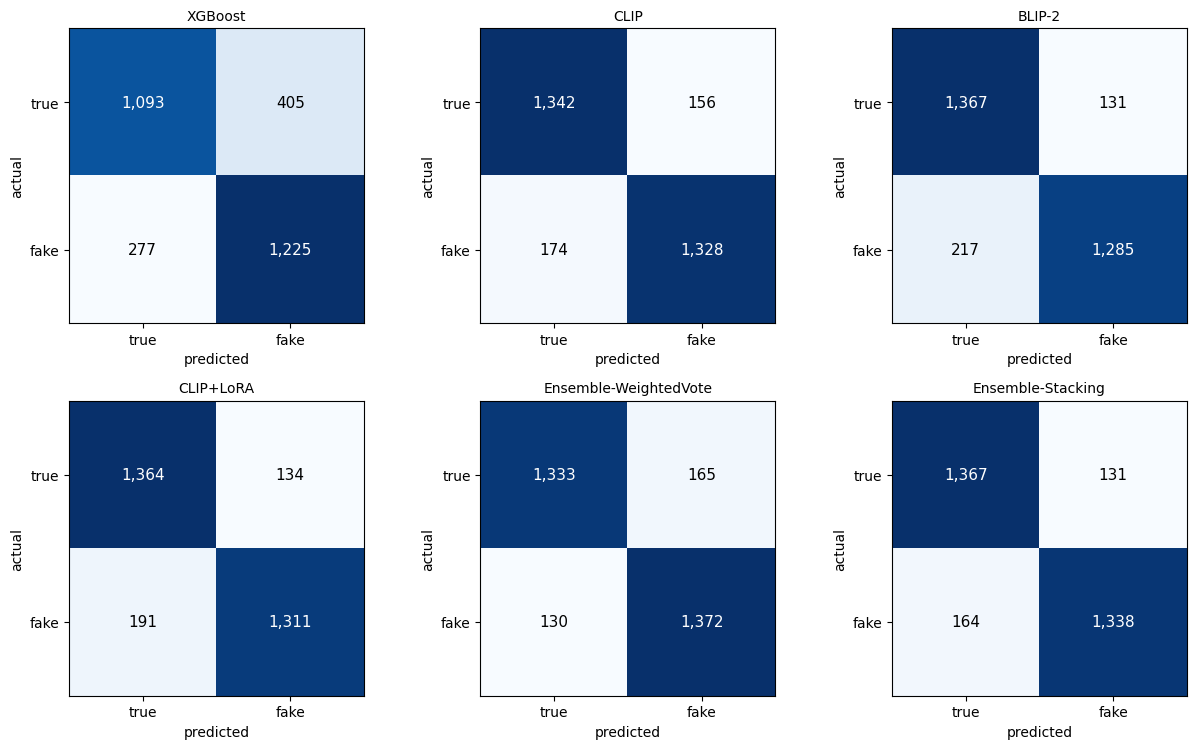

[figure] /content/drive/MyDrive/fake_news_multimodal/results/figures/19_confusion_matrices.png


In [55]:
# ---- confusion matrices ----------------------------------------------
show_models = [BEST_TRAD, "CLIP", "BLIP-2"] + (["CLIP+LoRA"] if LORA_DONE else []) + \
              ["Ensemble-WeightedVote", "Ensemble-Stacking"]
ncol = 3; nrow = int(math.ceil(len(show_models)/ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.2*ncol, 3.8*nrow))
axes = np.atleast_1d(axes).ravel()
for ax, name in zip(axes, show_models):
    pred = (TEST_PROBS[name] >= PREDICTORS[name]["threshold"]).astype(int)
    cm = confusion_matrix(Y["test"], pred)
    ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i,j]:,}", ha="center", va="center",
                    color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=11)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["true", "fake"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["true", "fake"])
    ax.set_xlabel("predicted"); ax.set_ylabel("actual"); ax.set_title(name, fontsize=10)
for ax in axes[len(show_models):]: ax.axis("off")
savefig("19_confusion_matrices.png")

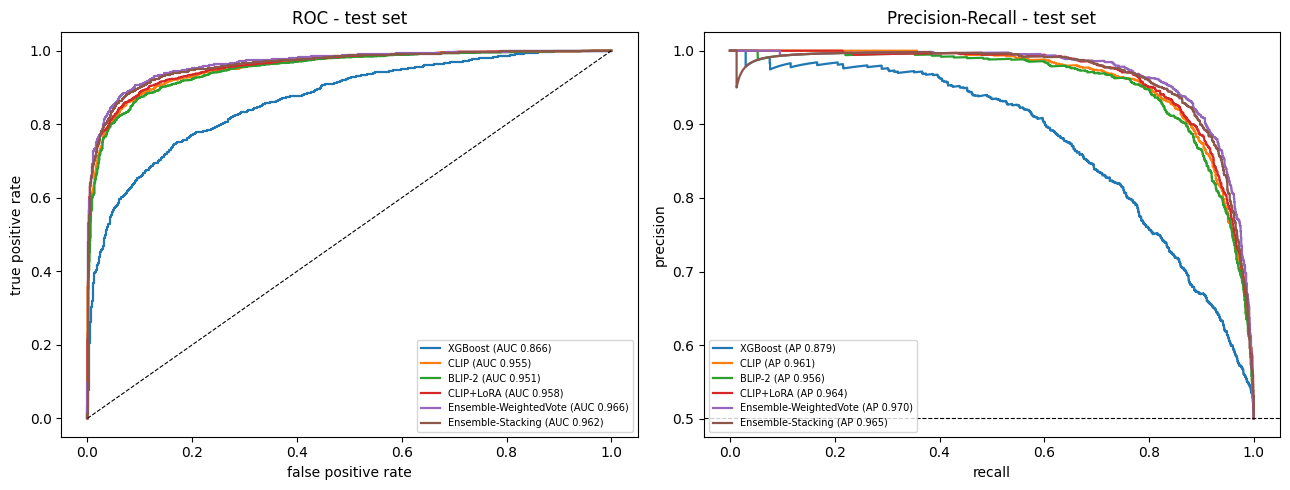

[figure] /content/drive/MyDrive/fake_news_multimodal/results/figures/19_roc_pr_curves.png


In [56]:
# ---- ROC and precision-recall curves ---------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name in show_models:
    p = TEST_PROBS[name]
    fpr, tpr, _ = roc_curve(Y["test"], p)
    axes[0].plot(fpr, tpr, lw=1.6, label=f"{name} (AUC {roc_auc_score(Y['test'], p):.3f})")
    pr, rc, _ = precision_recall_curve(Y["test"], p)
    axes[1].plot(rc, pr, lw=1.6,
                 label=f"{name} (AP {average_precision_score(Y['test'], p):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=0.8)
axes[0].set_xlabel("false positive rate"); axes[0].set_ylabel("true positive rate")
axes[0].set_title("ROC - test set"); axes[0].legend(fontsize=7, loc="lower right")
axes[1].axhline(Y["test"].mean(), color="k", ls="--", lw=0.8)
axes[1].set_xlabel("recall"); axes[1].set_ylabel("precision")
axes[1].set_title("Precision-Recall - test set"); axes[1].legend(fontsize=7, loc="lower left")
savefig("19_roc_pr_curves.png")

---
# 20. Error Analysis


In [57]:
err = test_df.copy().reset_index(drop=True)
err["y"] = Y["test"]
for name in show_models:
    err[f"p_{name}"] = TEST_PROBS[name]
    err[f"pred_{name}"] = (TEST_PROBS[name] >= PREDICTORS[name]["threshold"]).astype(int)
err["clip_cos"] = CLIP_COS["test"]
err["blip2_itm"] = blip2_emb["test_itm"]

print("=== 1. ERROR BALANCE (test) ===")
rows = []
for name in show_models:
    tn, fp, fn, tp = confusion_matrix(err["y"], err[f"pred_{name}"]).ravel()
    rows.append({"model": name, "TP": tp, "TN": tn, "FP": fp, "FN": fn,
                 "FP_rate": round(fp/max(tn+fp, 1), 4), "FN_rate": round(fn/max(tp+fn, 1), 4)})
print(pd.DataFrame(rows).to_string(index=False))

=== 1. ERROR BALANCE (test) ===
                model   TP   TN  FP  FN  FP_rate  FN_rate
              XGBoost 1225 1093 405 277   0.2704   0.1844
                 CLIP 1328 1342 156 174   0.1041   0.1158
               BLIP-2 1285 1367 131 217   0.0874   0.1445
            CLIP+LoRA 1311 1364 134 191   0.0895   0.1272
Ensemble-WeightedVote 1372 1333 165 130   0.1101   0.0866
    Ensemble-Stacking 1338 1367 131 164   0.0874   0.1092


In [58]:
print("=== 2. ACCURACY BY SIX-WAY CATEGORY (fake subcategories only) ===")
sub = err[err["y"] == 1]
rows = []
for c in sorted(sub[LABEL6].unique()):
    s = sub[sub[LABEL6] == c]
    r = {"6way_code": c, "n_test": len(s)}
    for name in [BEST_TRAD, "CLIP", "BLIP-2", "Ensemble-WeightedVote"]:
        r[f"recall_{name}"] = round(float(s[f"pred_{name}"].mean()), 4)
    r["mean_clip_cos"] = round(float(s["clip_cos"].mean()), 4)
    rows.append(r)
cat_tbl = pd.DataFrame(rows).sort_values("recall_CLIP")
print(cat_tbl.to_string(index=False))
cat_tbl.to_csv(DIRS["metrics"] / "error_by_category.csv", index=False)
print("\nCategories are printed by raw Fakeddit code; recall is the fraction of that")
print("category the model correctly flags as fake. Lower = harder for that model.")

print("\n=== 3. CROSS-MODAL AGREEMENT ON CORRECT VS INCORRECT PREDICTIONS ===")
rows = []
for name in ["CLIP", "BLIP-2"]:
    ok = err[err[f"pred_{name}"] == err["y"]]
    bad = err[err[f"pred_{name}"] != err["y"]]
    sig = "clip_cos" if name == "CLIP" else "blip2_itm"
    rows.append({"model": name, "signal": sig,
                 "n_correct": len(ok), "mean_correct": round(float(ok[sig].mean()), 4),
                 "n_wrong": len(bad), "mean_wrong": round(float(bad[sig].mean()), 4)})
print(pd.DataFrame(rows).to_string(index=False))

=== 2. ACCURACY BY SIX-WAY CATEGORY (fake subcategories only) ===
 6way_code  n_test  recall_XGBoost  recall_CLIP  recall_BLIP-2  recall_Ensemble-WeightedVote  mean_clip_cos
         3      57          0.4561       0.5789         0.6842                        0.7368         0.2008
         1     140          0.7357       0.8071         0.7143                        0.8071         0.2893
         5     103          0.8350       0.8350         0.8155                        0.8641         0.2989
         2     513          0.7135       0.8499         0.7973                        0.8811         0.2543
         4     689          0.9347       0.9579         0.9478                        0.9811         0.2414

Categories are printed by raw Fakeddit code; recall is the fraction of that
category the model correctly flags as fake. Lower = harder for that model.

=== 3. CROSS-MODAL AGREEMENT ON CORRECT VS INCORRECT PREDICTIONS ===
 model    signal  n_correct  mean_correct  n_wrong  mean_wrong
 

=== 4. MODEL DISAGREEMENT ===
CLIP and BLIP-2 disagree on 306 of 3,000 test samples (10.2%)
  CLIP right,   BLIP-2 wrong : 162
  BLIP-2 right, CLIP wrong   : 144
  Weighted-vote ensemble accuracy on these disputed cases: 0.6340
  Ensemble accuracy on agreed cases: 0.9321

=== REPRESENTATIVE ERRORS (most confident mistakes, weighted-vote ensemble) ===
label_name  6_way_label  clip_cos  p_Ensemble-WeightedVote                                                                  original_text
      true            0  0.214385                 0.998903                                                                         whaaat
      fake            2  0.329285                 0.002497                this building in herat afghanistan that must be one strong pole
      fake            3  0.257799                 0.006824                                     florida woman robs postal worker with rope
      fake            2  0.290044                 0.007599                     policeman in hon

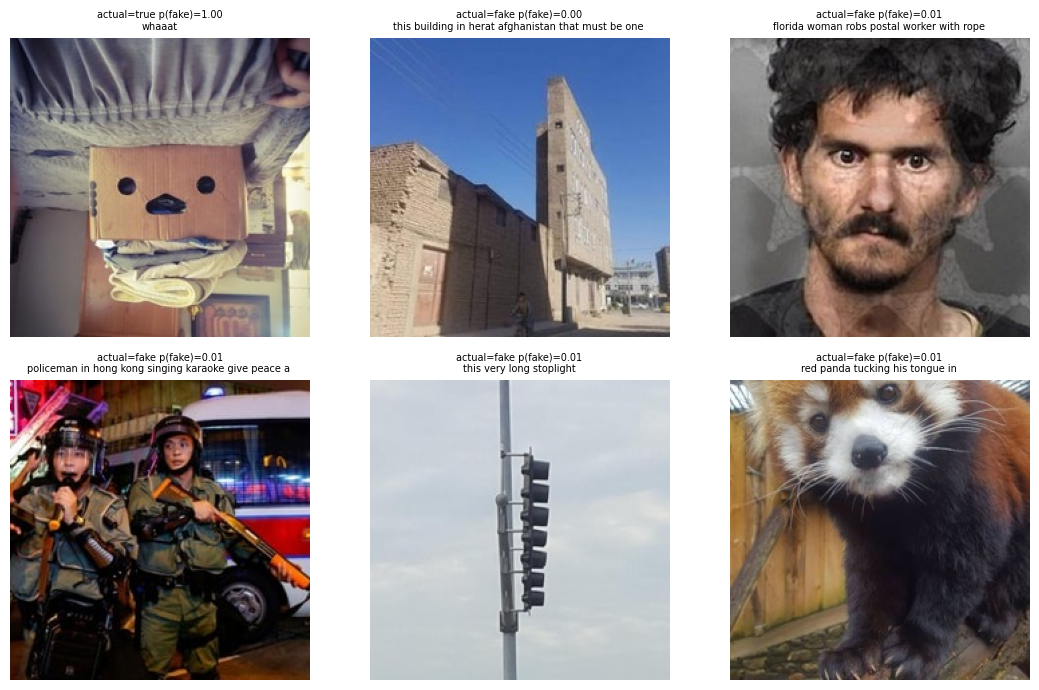

[figure] /content/drive/MyDrive/fake_news_multimodal/results/figures/20_confident_errors.png


In [59]:
print("=== 4. MODEL DISAGREEMENT ===")
dis = err[err["pred_CLIP"] != err["pred_BLIP-2"]]
print(f"CLIP and BLIP-2 disagree on {len(dis):,} of {len(err):,} test samples "
      f"({len(dis)/len(err)*100:.1f}%)")
if len(dis):
    print(f"  CLIP right,   BLIP-2 wrong : {int((dis['pred_CLIP'] == dis['y']).sum()):,}")
    print(f"  BLIP-2 right, CLIP wrong   : {int((dis['pred_BLIP-2'] == dis['y']).sum()):,}")
    print(f"  Weighted-vote ensemble accuracy on these disputed cases: "
          f"{float((dis['pred_Ensemble-WeightedVote'] == dis['y']).mean()):.4f}")
    print(f"  Ensemble accuracy on agreed cases: "
          f"{float((err.loc[err['pred_CLIP'] == err['pred_BLIP-2'], 'pred_Ensemble-WeightedVote'] == err.loc[err['pred_CLIP'] == err['pred_BLIP-2'], 'y']).mean()):.4f}")

print("\n=== REPRESENTATIVE ERRORS (most confident mistakes, weighted-vote ensemble) ===")
e = err.copy()
e["conf_err"] = np.where(e["y"] == 1, 1 - e["p_Ensemble-WeightedVote"], e["p_Ensemble-WeightedVote"])
worst = e[e["pred_Ensemble-WeightedVote"] != e["y"]].nlargest(8, "conf_err")
print(worst[["label_name", LABEL6, "clip_cos", "p_Ensemble-WeightedVote", "original_text"]]
      .assign(original_text=lambda d: d["original_text"].str.slice(0, 78)).to_string(index=False))

if len(worst):
    n = min(6, len(worst))
    fig, axs = plt.subplots(2, 3, figsize=(11, 7))
    for ax, (_, r) in zip(np.atleast_1d(axs).ravel(), worst.head(n).iterrows()):
        ax.imshow(read_image(r["offset"], r["length"])); ax.axis("off")
        ax.set_title(f"actual={r['label_name']} p(fake)={r['p_Ensemble-WeightedVote']:.2f}\n"
                     f"{r['original_text'][:52]}", fontsize=7)
    for ax in np.atleast_1d(axs).ravel()[n:]: ax.axis("off")
    savefig("20_confident_errors.png")

err.drop(columns=["offset", "length"]).to_csv(DIRS["predictions"] / "test_error_analysis.csv",
                                              index=False)

---
# 21. Final Results

Every number below was produced by code executed in this notebook. Anything that did not run prints `NOT YET EXECUTED`.

In [60]:
EXPECTED = ["LogisticRegression", "DecisionTree", "RandomForest", "XGBoost", "KNN",
            "CLIP", "BLIP-2", "CLIP+LoRA",
            "Ensemble-SoftVote", "Ensemble-WeightedVote", "Ensemble-Stacking"]

rows = []
for name in EXPECTED:
    r = RESULTS.get(name, {}).get("test")
    if r is None:
        rows.append({"Model": name, "Accuracy": "NOT YET EXECUTED", "Precision": "NOT YET EXECUTED",
                     "Recall": "NOT YET EXECUTED", "F1": "NOT YET EXECUTED",
                     "AUC": "NOT YET EXECUTED"})
    else:
        rows.append({"Model": name, "Accuracy": round(r["accuracy"], 4),
                     "Precision": round(r["precision"], 4), "Recall": round(r["recall"], 4),
                     "F1": round(r["f1"], 4), "AUC": round(r["auc_roc"], 4)})
main_tbl = pd.DataFrame(rows)
print("=" * 78)
print("FINAL COMPARISON - OFFICIAL TEST SET".center(78))
print("=" * 78)
print(main_tbl.to_string(index=False))
main_tbl.to_csv(DIRS["metrics"] / "final_results_table.csv", index=False)

print("\n" + "=" * 78)
print("PERFORMANCE VERSUS COMPUTATIONAL COST".center(78))
print("=" * 78)
cost = final_tbl[["Model", "Family", "F1", "AUC", "TrainSec", "InferSec"]].copy()
print(cost.to_string(index=False))
cost.to_csv(DIRS["metrics"] / "cost_table.csv", index=False)

                     FINAL COMPARISON - OFFICIAL TEST SET                     
                Model  Accuracy  Precision  Recall     F1    AUC
   LogisticRegression    0.7310     0.6960  0.8216 0.7536 0.8245
         DecisionTree    0.6583     0.6792  0.6019 0.6382 0.6157
         RandomForest    0.7303     0.6999  0.8076 0.7499 0.8191
              XGBoost    0.7727     0.7515  0.8156 0.7822 0.8664
                  KNN    0.5647     0.5380  0.9248 0.6802 0.6828
                 CLIP    0.8900     0.8949  0.8842 0.8895 0.9552
               BLIP-2    0.8840     0.9075  0.8555 0.8807 0.9509
            CLIP+LoRA    0.8917     0.9073  0.8728 0.8897 0.9584
    Ensemble-SoftVote    0.9017     0.9159  0.8848 0.9001 0.9628
Ensemble-WeightedVote    0.9017     0.8926  0.9134 0.9029 0.9656
    Ensemble-Stacking    0.9017     0.9108  0.8908 0.9007 0.9619

                    PERFORMANCE VERSUS COMPUTATIONAL COST                     
                Model      Family       F1      AUC  TrainSec

In [61]:
print("=" * 78)
print("RESEARCH QUESTIONS".center(78))
print("=" * 78)

trad_best_f1 = max(RESULTS[n]["test"]["f1"] for n in
                   ["LogisticRegression", "DecisionTree", "RandomForest", "XGBoost", "KNN"]
                   if n in RESULTS and "test" in RESULTS[n])
trad_best_auc = max(RESULTS[n]["test"]["auc_roc"] for n in
                    ["LogisticRegression", "DecisionTree", "RandomForest", "XGBoost", "KNN"]
                    if n in RESULTS and "test" in RESULTS[n])
vlm_best_f1 = max(RESULTS[n]["test"]["f1"] for n in ["CLIP", "BLIP-2"] if n in RESULTS)
vlm_best_auc = max(RESULTS[n]["test"]["auc_roc"] for n in ["CLIP", "BLIP-2"] if n in RESULTS)

print("\nRQ1 - traditional ML versus pre-trained vision-language models")
print(f"  Best traditional : F1 {trad_best_f1:.4f} | AUC {trad_best_auc:.4f}")
print(f"  Best VLM         : F1 {vlm_best_f1:.4f} | AUC {vlm_best_auc:.4f}")
print(f"  Difference       : F1 {vlm_best_f1-trad_best_f1:+.4f} | AUC {vlm_best_auc-trad_best_auc:+.4f}")

print("\nRQ2 - CLIP versus BLIP-2 on cross-modal semantic coherence")
print(f"  Validation, multi-seed: {RQ2_VERDICT}")
print(f"  Test  CLIP   F1 {RESULTS['CLIP']['test']['f1']:.4f} | AUC {RESULTS['CLIP']['test']['auc_roc']:.4f}")
print(f"  Test  BLIP-2 F1 {RESULTS['BLIP-2']['test']['f1']:.4f} | AUC {RESULTS['BLIP-2']['test']['auc_roc']:.4f}")
print("  Note: the multi-seed validation comparison, not the single test figure, is the")
print("        basis for any claim - a single test run cannot separate models whose gap")
print("        is smaller than seed-to-seed noise.")

print("\n" + "=" * 78)
print("LIMITATIONS TO REPORT IN THE DISSERTATION".center(78))
print("=" * 78)
lims = [
 f"1. Working set is {len(ALL_DF):,} samples, not the proposal's 100k-200k. Constrained by "
 f"image-link mortality and Colab wall-clock, not by GPU. Widens confidence intervals; the "
 f"between-model comparison stays valid because all models share the identical split.",
 f"2. Fakeddit's published train/validate/test split was discarded and re-split at group level "
 f"to prevent repost leakage. Results are therefore not comparable to published Fakeddit baselines.",
 f"3. Only samples whose image URL was still live were usable. Link mortality may not be random "
 f"with respect to content, so the working set may not represent the full corpus.",
 f"4. BLIP-2 uses the ITM retrieval checkpoint, required for the image-text matching score. "
 f"Findings apply to that configuration, not to BLIP-2 captioning variants.",
 f"5. The stacking meta-learner was fitted on out-of-fold training predictions rather than "
 f"validation outputs, because validation was already used for early stopping, thresholds and "
 f"voting weights.",
 f"6. Variability is estimated across {len(CFG['head_seeds'])} seeds for the VLM heads and "
 f"{CFG['cv_folds']}-fold CV for the traditional models. Differences smaller than that spread "
 f"should not be reported as findings.",
]
if not LORA_DONE:
    lims.append("7. LoRA fine-tuning did not run, so the frozen-versus-adapted comparison is absent.")
for l in lims: print(f"\n{l}")
json.dump(lims, open(DIRS["metrics"] / "limitations.json", "w"), indent=2)

                              RESEARCH QUESTIONS                              

RQ1 - traditional ML versus pre-trained vision-language models
  Best traditional : F1 0.7822 | AUC 0.8664
  Best VLM         : F1 0.8895 | AUC 0.9552
  Difference       : F1 +0.1072 | AUC +0.0889

RQ2 - CLIP versus BLIP-2 on cross-modal semantic coherence
  Validation, multi-seed: CLIP higher by 0.0069 AUC (7.6 SE)
  Test  CLIP   F1 0.8895 | AUC 0.9552
  Test  BLIP-2 F1 0.8807 | AUC 0.9509
  Note: the multi-seed validation comparison, not the single test figure, is the
        basis for any claim - a single test run cannot separate models whose gap
        is smaller than seed-to-seed noise.

                  LIMITATIONS TO REPORT IN THE DISSERTATION                   

1. Working set is 20,002 samples, not the proposal's 100k-200k. Constrained by image-link mortality and Colab wall-clock, not by GPU. Widens confidence intervals; the between-model comparison stays valid because all models share the identi

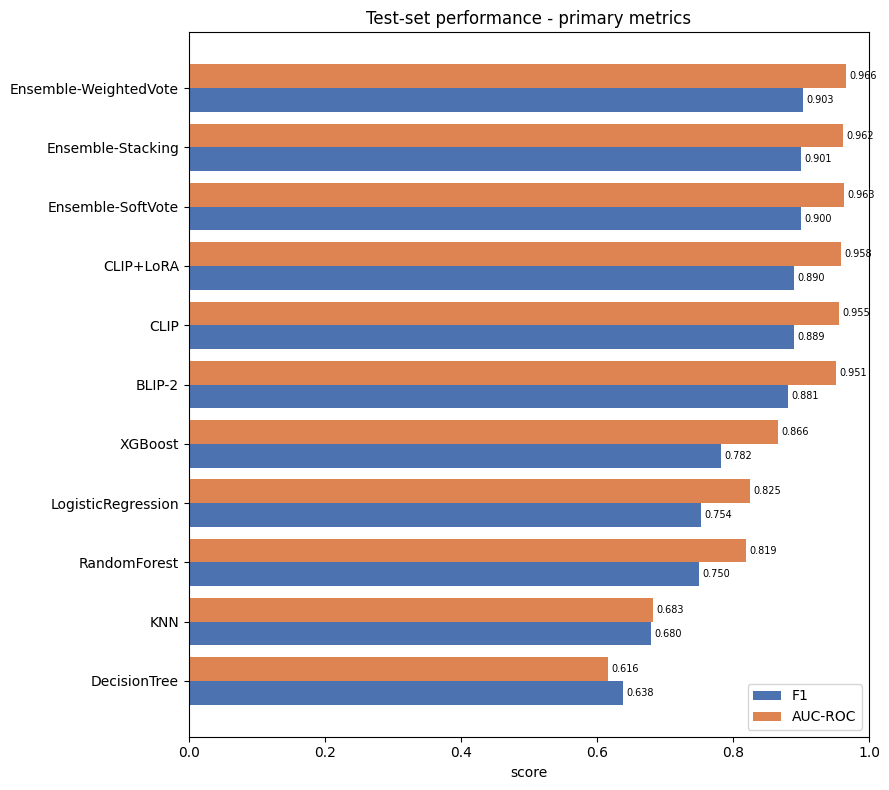

[figure] /content/drive/MyDrive/fake_news_multimodal/results/figures/21_final_comparison.png


In [62]:
# ---- summary figure ---------------------------------------------------
plot_df = final_tbl.sort_values("F1")
fig, ax = plt.subplots(figsize=(9, 0.5*len(plot_df)+2.5))
ypos = np.arange(len(plot_df))
ax.barh(ypos - 0.2, plot_df["F1"], height=0.4, label="F1", color="#4C72B0")
ax.barh(ypos + 0.2, plot_df["AUC"], height=0.4, label="AUC-ROC", color="#DD8452")
ax.set_yticks(ypos); ax.set_yticklabels(plot_df["Model"])
ax.set_xlim(0, 1); ax.set_xlabel("score"); ax.legend()
ax.set_title("Test-set performance - primary metrics")
for i, (f, a) in enumerate(zip(plot_df["F1"], plot_df["AUC"])):
    ax.text(f+0.005, i-0.2, f"{f:.3f}", va="center", fontsize=7)
    ax.text(a+0.005, i+0.2, f"{a:.3f}", va="center", fontsize=7)
savefig("21_final_comparison.png")

---
# 22. Save Research Outputs

Everything needed to reconstruct or defend the experiment is written to Drive: the processed dataset, the one official split, cached embeddings, checkpoints, per-sample predictions, metrics, figures, and a run manifest recording dataset provenance, model checkpoints, library versions, hardware, batch sizes and seed.

In [63]:
MANIFEST = {
    "run_completed_utc": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),
    "seed": SEED,
    "dataset": PROVENANCE,
    "label_mapping": {"true_2way_code": int(TRUE_CODE), "positive_class": "fake (label=1)"},
    "working_set": {"total": int(len(ALL_DF)),
                    "train": int(len(train_df)), "validation": int(len(val_df)),
                    "test": int(len(test_df)),
                    "groups": int(pd.concat([train_df, val_df, test_df])["group_id"].nunique())},
    "models": {"resnet50": CFG["resnet_weights"], "clip": CFG["clip_model"],
               "blip2": CFG["blip2_model"],
               "lora_executed": bool(LORA_DONE)},
    "hardware": HW, "batch_sizes": BATCH, "versions": VERSIONS,
    "config": {k: v for k, v in CFG.items() if k not in ("hardware", "versions")},
    "ensemble_weights": WEIGHTS,
    "rq2_verdict": RQ2_VERDICT,
    "leakage_checks_passed": int((leakage_report["status"] == "PASS").sum()),
}
with open(DIRS["logs"] / "run_manifest.json", "w") as f:
    json.dump(MANIFEST, f, indent=2, default=str)

pd.concat([train_df.assign(split="train"), val_df.assign(split="validation"),
           test_df.assign(split="test")], ignore_index=True)\
  .to_parquet(DIRS["processed"] / "final_working_dataset.parquet", index=False)

print("=== SAVED TO GOOGLE DRIVE ===")
for label, p in [("run manifest", DIRS["logs"]/"run_manifest.json"),
                 ("dataset provenance", DIRS["logs"]/"dataset_provenance.json"),
                 ("config", DIRS["logs"]/"config.json"),
                 ("processed dataset", DIRS["processed"]/"final_working_dataset.parquet"),
                 ("grouped dataset", DIRS["processed"]/"grouped.parquet"),
                 ("official split", DIRS["splits"]),
                 ("image blob + index", DIRS["images"]),
                 ("embeddings", DIRS["embeddings"]),
                 ("checkpoints", DIRS["checkpoints"]),
                 ("metrics", DIRS["metrics"]),
                 ("figures", DIRS["figures"]),
                 ("predictions", DIRS["predictions"])]:
    if Path(p).is_dir():
        n = len(list(Path(p).glob("*")))
        sz = sum(f.stat().st_size for f in Path(p).rglob("*") if f.is_file())/2**20
        print(f"  {label:<22} {n:>3} files  {sz:>8.1f} MB  {p}")
    else:
        print(f"  {label:<22}            {Path(p).stat().st_size/2**10:>8.1f} KB  {p}")

print("\n" + "=" * 78)
print("PIPELINE COMPLETE".center(78))
print("=" * 78)
print(f"Working set {len(ALL_DF):,} samples | {len(PREDICTORS)} models evaluated on the "
      f"same held-out test set")
print(f"Best by F1: {final_tbl.iloc[0]['Model']} (F1 {final_tbl.iloc[0]['F1']:.4f}, "
      f"AUC {final_tbl.iloc[0]['AUC']:.4f})")
print("\nTo scale towards the proposal's 100k-200k: raise CFG['target_n'] in Section 5 and")
print("re-run. Sections 6-13 resume from cache; Section 9 fetches only the new images.")

=== SAVED TO GOOGLE DRIVE ===
  run manifest                           3.3 KB  /content/drive/MyDrive/fake_news_multimodal/logs/run_manifest.json
  dataset provenance                     1.0 KB  /content/drive/MyDrive/fake_news_multimodal/logs/dataset_provenance.json
  config                                 1.4 KB  /content/drive/MyDrive/fake_news_multimodal/logs/config.json
  processed dataset                   3652.0 KB  /content/drive/MyDrive/fake_news_multimodal/data/processed/final_working_dataset.parquet
  grouped dataset                     8060.3 KB  /content/drive/MyDrive/fake_news_multimodal/data/processed/grouped.parquet
  official split           3 files       4.7 MB  /content/drive/MyDrive/fake_news_multimodal/data/splits
  image blob + index       2 files     374.9 MB  /content/drive/MyDrive/fake_news_multimodal/data/images
  embeddings               3 files     114.4 MB  /content/drive/MyDrive/fake_news_multimodal/embeddings
  checkpoints              3 files     592.6 M

10 RANDOM HELD-OUT SAMPLES   (seed=42, grid verdict from Ensemble-WeightedVote)
 row                                            text actual               6-way   ITM   cos  P(Ensemble-WeightedVote) pred  ok models_correct
 257 security guard avoids jail by blaming bollyw...   TRUE True (genuine news) 0.399 0.299                     0.009 TRUE yes           9/11
2315                             i took a stab at it   FAKE    False Connection 0.053 0.177                     0.951 FAKE yes           9/11
 266                                 in for the kill   FAKE    False Connection 0.247 0.229                     0.978 FAKE yes          11/11
1959                           this really chill dog   TRUE True (genuine news) 0.292 0.295                     0.195 TRUE yes           9/11
1314                                its an airstrike   FAKE    False Connection 0.087 0.194                     0.850 FAKE yes          11/11
1296 words of inspiration in the directions for m...   TRUE True (ge

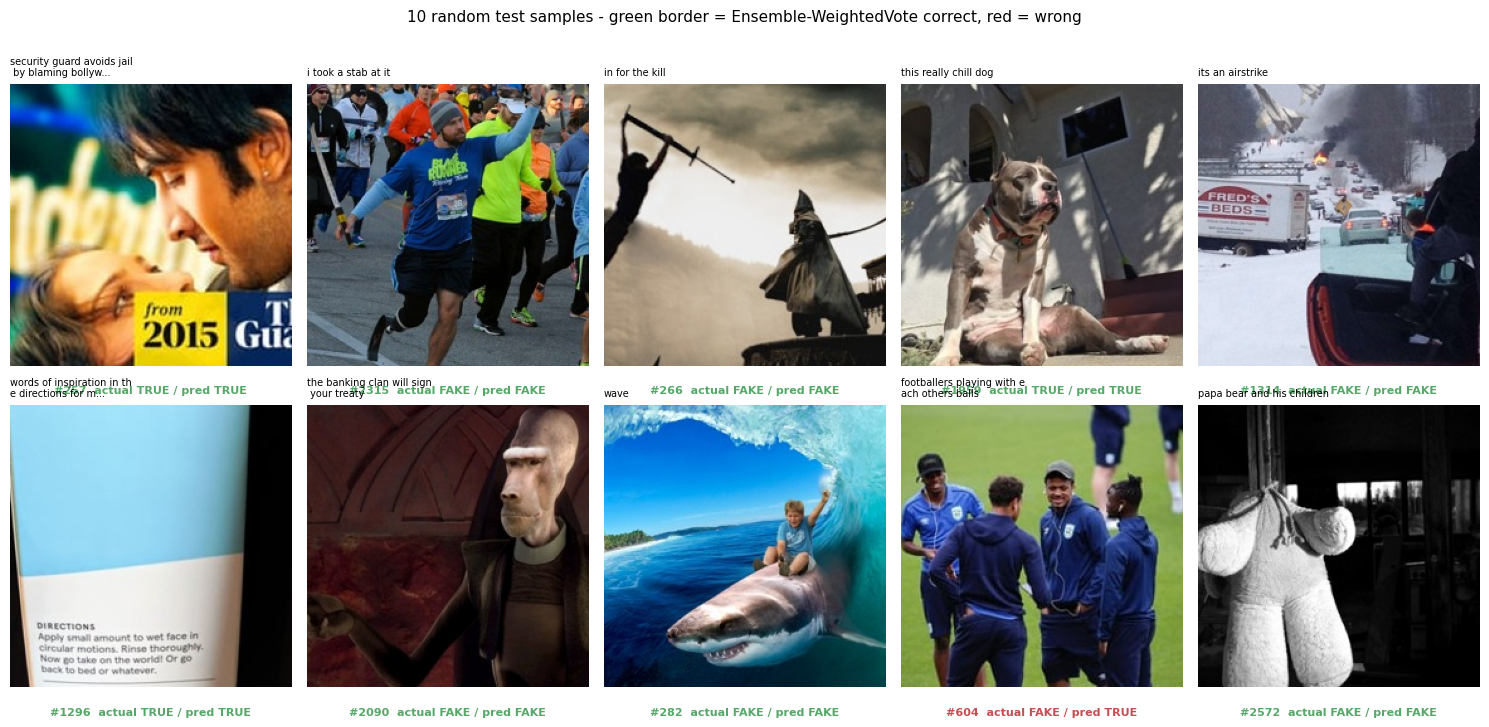

In [75]:
# ============================================================================
# BATCH TEST-SET INSPECTION  --  N random held-out samples at once
#
# Paste as a new cell AFTER the show_test_sample cell (it reuses FAKE6 and
# show_test_sample for drill-down).
#
# Same method note as before: this only LOOKS UP probabilities that Section 19
# already computed. Nothing is retrained or retuned.
# ============================================================================

import numpy as np, pandas as pd, matplotlib.pyplot as plt


def sample_test_batch(n=10, want=None, seed=42, ref="Ensemble-WeightedVote",
                      show_grid=True):
    """Score n random held-out samples and summarise them together.
       want : None | 'fake' | 'true'   -> restrict to one ground-truth class
       ref  : which model's verdict is drawn on the grid
    """
    if ref not in TEST_PROBS:
        ref = "CLIP"

    mask = np.ones(len(test_df), dtype=bool)
    if want == "fake": mask &= (Y["test"] == 1)
    if want == "true": mask &= (Y["test"] == 0)
    pool = np.flatnonzero(mask)

    rng  = np.random.default_rng(seed)
    idxs = rng.choice(pool, size=min(n, len(pool)), replace=False)

    # ---- one summary row per sample ---------------------------------------
    summary, per_model = [], {m: 0 for m in TEST_PROBS}
    for i in idxs:
        i = int(i)
        row = test_df.iloc[i]
        y   = int(Y["test"][i])
        six = int(row[LABEL6]) if LABEL6 in test_df.columns else None

        n_ok = 0
        for m in TEST_PROBS:
            pred = int(TEST_PROBS[m][i] >= PREDICTORS[m]["threshold"])
            if pred == y:
                per_model[m] += 1
                n_ok += 1

        p_ref = float(TEST_PROBS[ref][i])
        v_ref = int(p_ref >= PREDICTORS[ref]["threshold"])

        summary.append({
            "row": i,
            "text": (row["original_text"][:44] + "..."
                     if len(row["original_text"]) > 44 else row["original_text"]),
            "actual": "FAKE" if y else "TRUE",
            "6-way": FAKE6.get(six, six),
            "ITM": round(float(blip2_emb["test_itm"][i]), 3),
            "cos": round(float(CLIP_COS["test"][i]), 3),
            f"P({ref})": round(p_ref, 3),
            "pred": "FAKE" if v_ref else "TRUE",
            "ok": "yes" if v_ref == y else "NO",
            "models_correct": f"{n_ok}/{len(TEST_PROBS)}",
        })

    sm = pd.DataFrame(summary)
    print("=" * 100)
    print(f"{len(idxs)} RANDOM HELD-OUT SAMPLES   (seed={seed}, "
          f"grid verdict from {ref})")
    print("=" * 100)
    print(sm.to_string(index=False))

    # ---- per-model tally over this batch ----------------------------------
    tally = (pd.DataFrame([{"Model": m, "correct": c,
                            "of": len(idxs),
                            "rate": round(c / len(idxs), 3)}
                           for m, c in per_model.items()])
             .sort_values("correct", ascending=False))
    print(f"\n=== PER-MODEL SCORE ON THESE {len(idxs)} SAMPLES ===")
    print(tally.to_string(index=False))
    print("\n[warning] A sample this small is for qualitative inspection only.")
    print("          Report the Section 21 table, not these counts.")

    # ---- grid --------------------------------------------------------------
    if show_grid:
        ncol = 5
        nrow = int(np.ceil(len(idxs) / ncol))
        fig, axes = plt.subplots(nrow, ncol, figsize=(3.0 * ncol, 3.6 * nrow))
        axes = np.atleast_1d(axes).ravel()

        for ax, rec in zip(axes, summary):
            i = rec["row"]
            r = test_df.iloc[i]
            ax.imshow(read_image(r["offset"], r["length"]))
            ax.axis("off")
            good = rec["ok"] == "yes"
            ax.set_title("\n".join([rec["text"][j:j+26]
                                    for j in range(0, len(rec["text"]), 26)][:3]),
                         fontsize=7, loc="left")
            ax.text(0.5, -0.10,
                    f"#{i}  actual {rec['actual']} / pred {rec['pred']}",
                    transform=ax.transAxes, ha="center", fontsize=8,
                    fontweight="bold", color="#55A868" if good else "#C44E52")
            for sp in ax.spines.values():
                sp.set_visible(True); sp.set_linewidth(2.5)
                sp.set_color("#55A868" if good else "#C44E52")
            ax.set_frame_on(True)

        for ax in axes[len(idxs):]:
            ax.axis("off")
        fig.suptitle(f"{len(idxs)} random test samples - "
                     f"green border = {ref} correct, red = wrong", fontsize=11)
        plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

    return sm


# ============================================================================
# RUN
# ============================================================================

# 10 random samples across both classes
batch = sample_test_batch(n=10, seed=42)

# then drill into any interesting row from the table above, e.g.
# show_test_sample(index=int(batch.iloc[3]["row"]))

# a batch of fakes only - useful for spotting which 6-way categories fail
# sample_test_batch(n=10, want="fake", seed=7)

=== LEARNING CURVE (validation AUC vs training set size) ===

  CLIP      10%  n= 1,400  seed 42  val AUC 0.9316
  CLIP      10%  n= 1,400  seed 43  val AUC 0.9347
  CLIP      10%  n= 1,400  seed 44  val AUC 0.9273
  CLIP      25%  n= 3,501  seed 42  val AUC 0.9407
  CLIP      25%  n= 3,501  seed 43  val AUC 0.9412
  CLIP      25%  n= 3,501  seed 44  val AUC 0.9456
  CLIP      50%  n= 7,002  seed 42  val AUC 0.9495
  CLIP      50%  n= 7,002  seed 43  val AUC 0.9527
  CLIP      50%  n= 7,002  seed 44  val AUC 0.9481
  CLIP      75%  n=10,501  seed 42  val AUC 0.9577
  CLIP      75%  n=10,501  seed 43  val AUC 0.9578
  CLIP      75%  n=10,501  seed 44  val AUC 0.9594
  CLIP     100%  n=14,002  seed 42  val AUC 0.9601
  CLIP     100%  n=14,002  seed 43  val AUC 0.9591
  CLIP     100%  n=14,002  seed 44  val AUC 0.9599
  BLIP-2    10%  n= 1,400  seed 42  val AUC 0.9209
  BLIP-2    10%  n= 1,400  seed 43  val AUC 0.9178
  BLIP-2    10%  n= 1,400  seed 44  val AUC 0.9193
  BLIP-2    25%  n= 

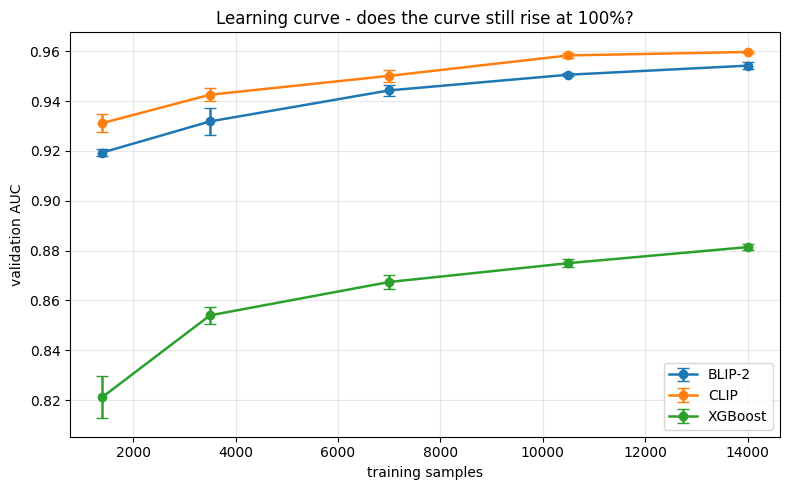


Saved to /content/drive/MyDrive/fake_news_multimodal/results/metrics/learning_curve.csv


In [74]:
# ============================================================================
# LEARNING CURVE  --  is 20,000 samples the bottleneck, or the representation?
#
# Paste as a new cell AFTER Section 16 (both heads trained).
#
# METHOD: retrain each head on 10/25/50/75/100% of the TRAINING split and
# score on VALIDATION. The test split is never touched, so this is a legal
# experiment - it uses no information that was not already available before
# Section 19 unlocked the test set.
#
# COST: the CLIP and BLIP-2 features are already cached, so nothing is
# re-extracted. Only the ~1.2M-parameter heads are refitted.
# ============================================================================

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.metrics import roc_auc_score

FRACTIONS  = [0.10, 0.25, 0.50, 0.75, 1.00]
SEEDS      = CFG["head_seeds"]              # [42, 43, 44]
RUN_TRAD   = True                           # set False if XGBoost refits are slow


def _subsample(n_total, frac, y, seed):
    """Class-stratified subsample of the training rows."""
    rng = np.random.default_rng(seed)
    idx = []
    for lab in (0, 1):
        pool = np.flatnonzero(y == lab)
        idx.append(rng.choice(pool, size=int(round(len(pool) * frac)), replace=False))
    out = np.concatenate(idx)
    rng.shuffle(out)
    return out


def learning_curve_head(FEATS, tag):
    """Refit the standard head at each fraction, over every seed."""
    rows = []
    for frac in FRACTIONS:
        for seed in SEEDS:
            sel = _subsample(len(Y["train"]), frac, Y["train"], seed)
            mdl, _ = train_head(FEATS["train"][sel], Y["train"][sel],
                                FEATS["validation"], Y["validation"],
                                seed, f"{tag}@{frac}", verbose=False)
            auc = roc_auc_score(Y["validation"],
                                head_predict(mdl, FEATS["validation"]))
            rows.append({"model": tag, "frac": frac,
                         "n_train": len(sel), "seed": seed, "val_auc": float(auc)})
            print(f"  {tag:<8} {int(frac*100):>3}%  n={len(sel):>6,}  "
                  f"seed {seed}  val AUC {auc:.4f}")
    return rows


def learning_curve_trad(name):
    """Same curve for the best traditional model, reusing its tuned params."""
    rows = []
    for frac in FRACTIONS:
        for seed in SEEDS:
            sel = _subsample(len(Y["train"]), frac, Y["train"], seed)
            est = clone(trad_models[name])
            est.fit(TRAD["train"][sel], Y["train"][sel])
            auc = roc_auc_score(Y["validation"],
                                est.predict_proba(TRAD["validation"])[:, 1])
            rows.append({"model": name, "frac": frac,
                         "n_train": len(sel), "seed": seed, "val_auc": float(auc)})
            print(f"  {name:<8} {int(frac*100):>3}%  n={len(sel):>6,}  "
                  f"seed {seed}  val AUC {auc:.4f}")
    return rows


# ---------------------------------------------------------------- run -------
print("=== LEARNING CURVE (validation AUC vs training set size) ===\n")
records = []
records += learning_curve_head(CLIP_FEATS,  "CLIP")
records += learning_curve_head(BLIP2_FEATS, "BLIP-2")
if RUN_TRAD:
    records += learning_curve_trad(BEST_TRAD)

lc = pd.DataFrame(records)
agg = (lc.groupby(["model", "frac", "n_train"])["val_auc"]
         .agg(mean="mean", sd="std").reset_index())

print("\n=== MEAN +/- SD ACROSS SEEDS ===")
print(agg.to_string(index=False))

# ---- the number that answers the question ---------------------------------
print("\n=== MARGINAL GAIN FROM THE LAST 25% OF THE DATA ===")
for m in agg["model"].unique():
    s = agg[agg["model"] == m].sort_values("frac")
    gain = s.iloc[-1]["mean"] - s.iloc[-2]["mean"]
    noise = s["sd"].mean()
    verdict = ("data-limited - more data should help"
               if gain > noise else
               "saturated - more data is unlikely to help")
    print(f"  {m:<10} 75% -> 100%: {gain:+.4f} AUC   "
          f"(mean seed SD {noise:.4f})   -> {verdict}")

# ---- plot ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))
for m in agg["model"].unique():
    s = agg[agg["model"] == m].sort_values("n_train")
    ax.errorbar(s["n_train"], s["mean"], yerr=s["sd"].fillna(0),
                marker="o", capsize=4, lw=1.8, label=m)
ax.set_xlabel("training samples"); ax.set_ylabel("validation AUC")
ax.set_title("Learning curve - does the curve still rise at 100%?")
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

lc.to_csv(DIRS["metrics"] / "learning_curve.csv", index=False)
print(f"\nSaved to {DIRS['metrics'] / 'learning_curve.csv'}")